In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [189]:
df = pd.read_csv("../../dataset/preprocessed/final_merged.csv")  
target = "Prospect_Outcome"

=== TARGET DISTRIBUTION ===


,count,pct
Prospect_Outcome,,
Won,100087,89.29
Churned,12002,10.71


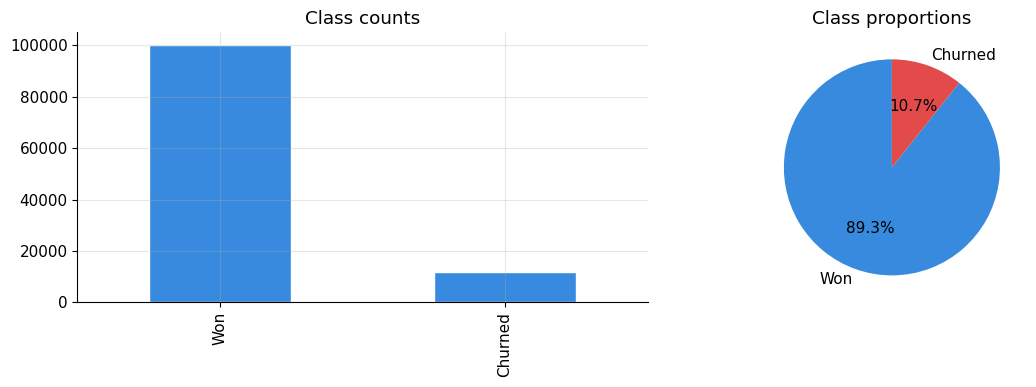

In [190]:
# 1. Target Distribution
print("=== TARGET DISTRIBUTION ===")
counts = df[target].value_counts()
pct    = df[target].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": counts, "pct": pct.round(2)})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind="bar", ax=axes[0], color="#378ADD", edgecolor="white")
axes[0].set_title("Class counts")
axes[0].set_xlabel("")

pct.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90,
         colors=["#378ADD","#E24B4A","#EF9F27","#1D9E75"])
axes[1].set_ylabel("")
axes[1].set_title("Class proportions")
plt.tight_layout()
plt.show()

## Data Quality Checks

In [191]:
# Zero and near-zero variance columns
print("\n=== ZERO / NEAR-ZERO VARIANCE ===")

def variance_report(df, threshold=0.01):
    rows = []
    for col in df.columns:
        if col == target:
            continue
        n_unique = df[col].nunique()
        top_freq = df[col].value_counts(normalize=True).iloc[0]
        rows.append({"column": col, "n_unique": n_unique,
                     "top_value_pct": round(top_freq * 100, 2)})
    report = pd.DataFrame(rows).sort_values("top_value_pct", ascending=False)
    
    zero_var    = report[report["n_unique"] == 1]
    near_zero   = report[(report["n_unique"] > 1) & (report["top_value_pct"] >= 99)]
    return report, zero_var, near_zero

report, zero_var, near_zero = variance_report(df)

print(f"\nZero variance (drop immediately): {len(zero_var)} columns")
display(zero_var)

print(f"\nNear-zero variance (top value ≥99%): {len(near_zero)} columns")
display(near_zero)

# Drop zero-variance columns
cols_to_drop = zero_var["column"].tolist()
print(f"\nDropping: {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)


=== ZERO / NEAR-ZERO VARIANCE ===

Zero variance (drop immediately): 1 columns


,column,n_unique,top_value_pct
343,missing_proforma,1,100.0



Near-zero variance (top value ≥99%): 52 columns


,column,n_unique,top_value_pct
286,cc_questions_harder_than_expected_max,2,99.99
71,rc_Explicit_Switching_Intent,2,99.98
290,cc_refund_discussed_max,2,99.97
287,cc_dissatisfaction_support_max,2,99.96
276,cc_agent_cross_sell_attempt_max,2,99.95
284,cc_dissatisfaction_time_to_complete_max,2,99.94
278,cc_business_struggles_financial_hardship_max,2,99.92
282,cc_login_issues_max,2,99.92
291,cc_contractor_suggest_leave_max,2,99.91
289,cc_pricing_sentiment_impact_max,2,99.89



Dropping: ['missing_proforma']


In [192]:
# Missing value audit
print("\n=== MISSING VALUE AUDIT ===")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"missing_count": missing,
                         "missing_pct": missing_pct})
miss_df = miss_df[miss_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

if miss_df.empty:
    print("No missing values found.")
else:
    display(miss_df)
    
    # Visual
    top_miss = miss_df.head(20)
    top_miss["missing_pct"].plot(kind="barh", figsize=(10, 5), color="#E24B4A")
    plt.xlabel("Missing %")
    plt.title("Top columns with missing values")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


=== MISSING VALUE AUDIT ===
No missing values found.


=== WHY WE DROP Closed_Date ===
Unique Closed_Date values : 1216
Unique Prospect_Renewal_Date values: 1243


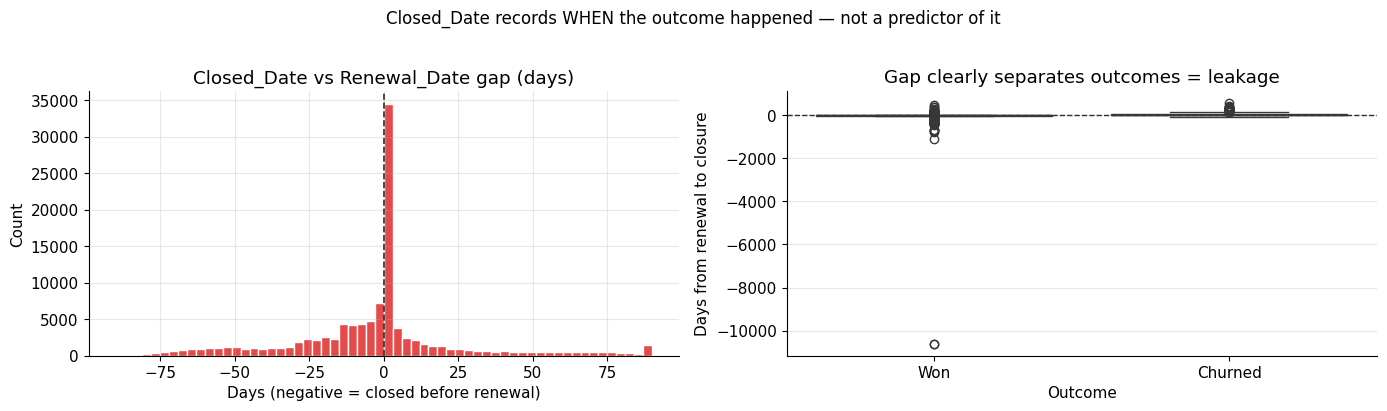

In [193]:
# 1. Show WHY we drop it — it mirrors the outcome event
print("=== WHY WE DROP Closed_Date ===")
print(f"Unique Closed_Date values : {df['Closed_Date'].nunique()}")
print(f"Unique Prospect_Renewal_Date values: {df['Prospect_Renewal_Date'].nunique()}")

# Check overlap: closed_date ≈ renewal_date for most rows
df["Closed_Date"] = pd.to_datetime(df["Closed_Date"], errors="coerce")
df["Prospect_Renewal_Date"] = pd.to_datetime(df["Prospect_Renewal_Date"], errors="coerce")

df["closed_vs_renewal_gap"] = (
    df["Closed_Date"] - df["Prospect_Renewal_Date"]
).dt.days

# Visualise the gap distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1 — gap distribution
axes[0].hist(
    df["closed_vs_renewal_gap"].dropna().clip(-90, 90),
    bins=60, color="#E24B4A", edgecolor="white"
)
axes[0].axvline(0, color="#2C2C2A", linestyle="--", linewidth=1.2)
axes[0].set_title("Closed_Date vs Renewal_Date gap (days)")
axes[0].set_xlabel("Days (negative = closed before renewal)")
axes[0].set_ylabel("Count")

# Plot 2 — gap by outcome: this is the smoking gun
# Update the palette to include all possible values in your target column
updated_palette = {
    "Won": "#1D9E75", 
    "Churned": "#E24B4A",
    "Won": "#1D9E75",   # Assigning same green as Renewed
    "Lost": "#E24B4A"   # Assigning same red as Churned
}

sns.boxplot(
    data=df,
    x=target,
    y="closed_vs_renewal_gap",
    palette=updated_palette, # Use the updated dictionary
    ax=axes[1]
)
axes[1].set_title("Gap clearly separates outcomes = leakage")
axes[1].set_xlabel("Outcome")
axes[1].set_ylabel("Days from renewal to closure")
axes[1].axhline(0, color="#2C2C2A", linestyle="--", linewidth=1)

plt.suptitle(
    "Closed_Date records WHEN the outcome happened — not a predictor of it",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

In [194]:
# Identify the bad record
bad_rows = df[df["closed_vs_renewal_gap"] < -1000]
print(f"Suspicious records: {len(bad_rows)}")
print(bad_rows[["year_key", "Closed_Date", "Prospect_Renewal_Date", 
                "closed_vs_renewal_gap", target]])

Suspicious records: 3
           year_key Closed_Date Prospect_Renewal_Date  closed_vs_renewal_gap  \
10603   JG3640_2024  2021-12-10            2024-11-25                  -1081   
104280  UQ7012_2050  2021-07-12            2050-07-24                 -10604   
104311  RE5625_2050  2021-06-21            2050-07-09                 -10610   

       Prospect_Outcome  
10603               Won  
104280              Won  
104311              Won  


In [195]:
dates_to_drop = ["Closed_Date", "Prospect_Renewal_Date",
                 "Registration_Date", "Proforma_Date", "Renewal_Month"]
df.drop(columns=[c for c in dates_to_drop if c in df.columns], inplace=True)
df.drop(columns=["Co_Ref"], errors="ignore", inplace=True)
print(f"Shape after drops: {df.shape}")

Shape after drops: (112089, 339)


In [196]:
# Separate true continuous numericals from score/ordinal columns
# Scores have very few unique values — treat as ordinal not continuous
score_cols = [
    "Sustainability_Score", "Auto_Renewal_Score", "Status_Scores",
    "Anchoring_Score", "Tenure_Scores", "Total_Renewal_Score_New",
    "Renewal_Score_At_Release"
]

# True continuous — meaningful distributions, need outlier checks
continuous_cols = [
    "Connection_Net", "Connection_Qty", "Starting_Connection_Net",
    "Starting_Connection_Qty", "Last_Years_Price", "Current_Anchorings",
    "Payment_Timeframe", "Proforma_Approved_Lists", "Tenure_Years",
    "Starting_Net", "Starting_Vat", "Starting_Gross",
    "Starting_Membership_Net", "Starting_Package_Net", "Starting_PQQ_Net",
    "Gross", "Membership_Net", "Package_Net", "PQQNet",
    "proforma_delay", "crm_contractor_sentiment_score", "crm_agent_chase_count"
]

# Keep only columns that exist in df
score_cols      = [c for c in score_cols if c in df.columns]
continuous_cols = [c for c in continuous_cols if c in df.columns]

print(f"Score/ordinal columns : {len(score_cols)}")
print(f"Continuous columns    : {len(continuous_cols)}")

Score/ordinal columns : 7
Continuous columns    : 22


In [197]:
print("\n=== CONTINUOUS COLUMN SUMMARY ===")

stats = df[continuous_cols].describe().T
stats["skewness"] = df[continuous_cols].skew().round(2)
stats["kurtosis"] = df[continuous_cols].kurt().round(2)
stats["missing%"] = (df[continuous_cols].isnull().sum() / len(df) * 100).round(2)

# Flag high skew (>1 or <-1) and extreme kurtosis (>3)
stats["high_skew"]  = stats["skewness"].abs() > 1
stats["heavy_tail"] = stats["kurtosis"] > 3

display(stats[["count","mean","std","min","50%","max",
               "skewness","kurtosis","missing%",
               "high_skew","heavy_tail"]])


=== CONTINUOUS COLUMN SUMMARY ===


,count,mean,std,min,50%,max,skewness,kurtosis,missing%,high_skew,heavy_tail
Connection_Net,112089.0,21.598792,160.796149,0.0,0.0,4752.0,15.29,317.06,0.0,True,True
Connection_Qty,112089.0,0.318006,2.179015,0.0,0.0,48.0,12.69,211.72,0.0,True,True
Starting_Connection_Net,112089.0,26.013097,186.491872,0.0,0.0,4752.0,13.71,244.92,0.0,True,True
Starting_Connection_Qty,112089.0,0.380787,2.518175,0.0,0.0,48.0,11.58,169.91,0.0,True,True
Last_Years_Price,112089.0,1056.500975,688.481817,0.0,919.0,18326.0,3.71,29.17,0.0,True,True
Current_Anchorings,112089.0,3.096084,6.491032,0.0,1.0,209.0,10.77,203.76,0.0,True,True
Payment_Timeframe,112089.0,-6.741259,51.756765,-10610.0,0.0,482.0,-153.55,31398.45,0.0,True,True
Proforma_Approved_Lists,112089.0,3.209887,6.544791,0.0,1.0,197.0,9.03,144.71,0.0,True,True
Tenure_Years,112089.0,6.849834,5.386363,0.0,5.0,30.0,0.86,-0.14,0.0,False,False
Starting_Net,112089.0,1085.679282,651.818186,0.0,924.0,17877.0,4.02,32.86,0.0,True,True


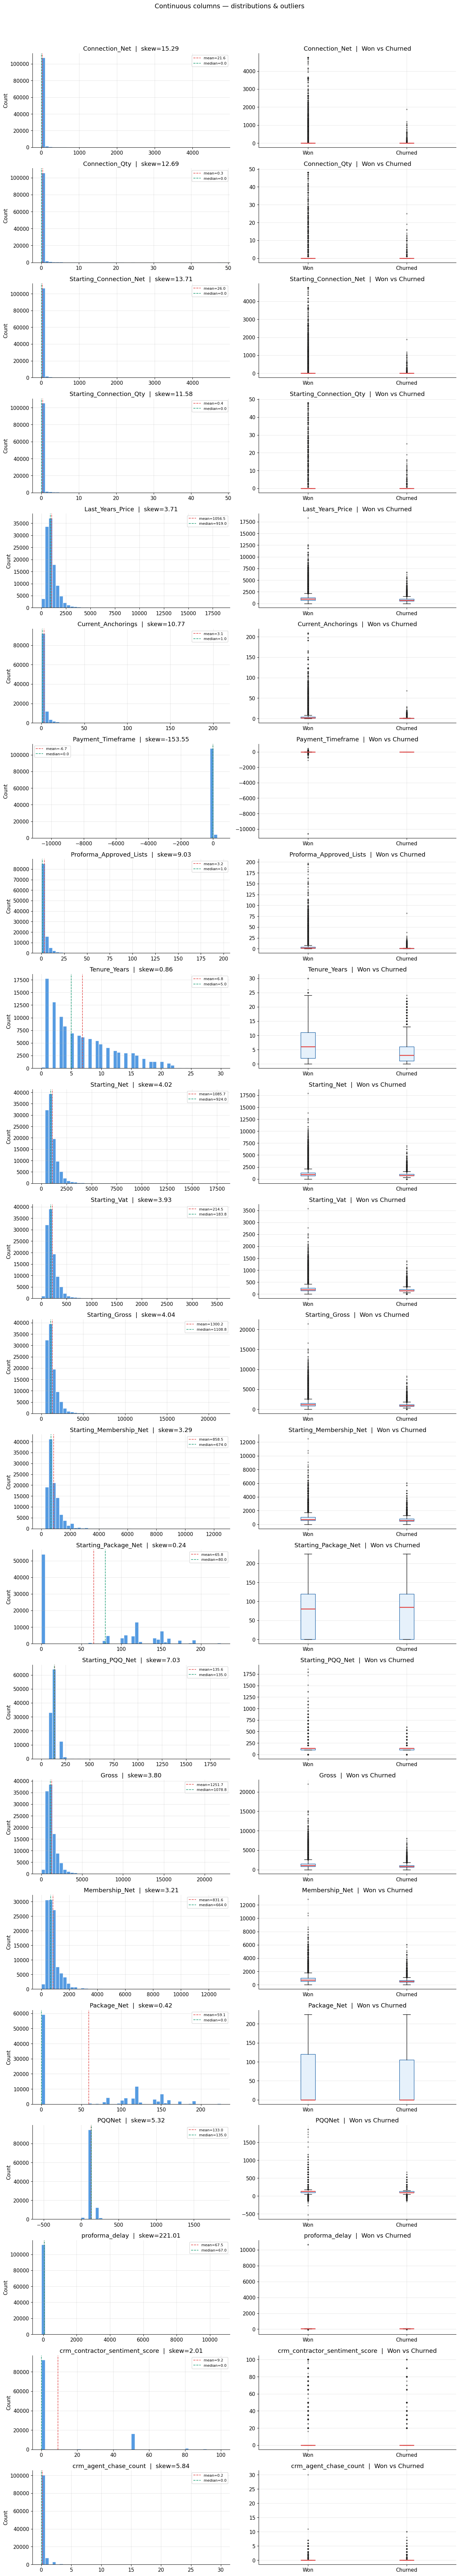

In [198]:
import warnings
warnings.filterwarnings("ignore")

n_cols = 2
n_rows = len(continuous_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
fig.suptitle("Continuous columns — distributions & outliers", 
             fontsize=14, y=1.01)

for i, col in enumerate(continuous_cols):
    data = df[col].dropna()
    
    # Histogram
    axes[i, 0].hist(data, bins=50, color="#378ADD", edgecolor="white", alpha=0.85)
    axes[i, 0].axvline(data.mean(),   color="#E24B4A", linestyle="--", 
                        linewidth=1.2, label=f"mean={data.mean():.1f}")
    axes[i, 0].axvline(data.median(), color="#1D9E75", linestyle="--", 
                        linewidth=1.2, label=f"median={data.median():.1f}")
    axes[i, 0].set_title(f"{col}  |  skew={data.skew():.2f}")
    axes[i, 0].legend(fontsize=8)
    axes[i, 0].set_ylabel("Count")
    
    # Boxplot — split by target to preview signal early
    won_data    = df[df[target] == "Won"][col].dropna()
    churn_data  = df[df[target] == "Churned"][col].dropna()
    
    axes[i, 1].boxplot(
        [won_data, churn_data],
        labels=["Won", "Churned"],
        patch_artist=True,
        boxprops=dict(facecolor="#E6F1FB", color="#185FA5"),
        medianprops=dict(color="#E24B4A", linewidth=2),
        flierprops=dict(marker="o", markersize=2, 
                        markerfacecolor="#888780", alpha=0.4)
    )
    axes[i, 1].set_title(f"{col}  |  Won vs Churned")
    
plt.tight_layout()
plt.show()

In [199]:
# Payment_Timeframe: min = -10,610 days (~29 years before renewal)
# proforma_delay: max = 10,657 days (~29 years)
# These are not outliers — they are bad data entries

print("=== PAYMENT_TIMEFRAME suspicious records ===")
print(df[df["Payment_Timeframe"] < -500][
    ["year_key", "Payment_Timeframe", target]
].head(20))

print("\n=== PROFORMA_DELAY suspicious records ===")
print(df[df["proforma_delay"] > 500][
    ["year_key", "proforma_delay", target]
].head(20))

# How many bad rows?
bad_payment  = (df["Payment_Timeframe"] < -500).sum()
bad_proforma = (df["proforma_delay"] > 500).sum()
print(f"\nPayment_Timeframe < -500 days : {bad_payment} rows")
print(f"proforma_delay    > 500 days  : {bad_proforma} rows")

=== PAYMENT_TIMEFRAME suspicious records ===
           year_key  Payment_Timeframe Prospect_Outcome
6892    VS5543_2024             -774.0              Won
10603   JG3640_2024            -1081.0              Won
51523   BP2744_2024             -730.0              Won
53308   ZU3941_2024             -689.0              Won
56967   MG8242_2024             -662.0              Won
103227  BE6380_2023             -674.0              Won
104280  UQ7012_2050           -10604.0              Won
104311  RE5625_2050           -10610.0              Won

=== PROFORMA_DELAY suspicious records ===
           year_key  proforma_delay Prospect_Outcome
104280  UQ7012_2050         10657.0              Won
104311  RE5625_2050         10642.0              Won

Payment_Timeframe < -500 days : 8 rows
proforma_delay    > 500 days  : 2 rows


In [200]:
df = df[df['Payment_Timeframe'] > -500]
df = df[df['proforma_delay'] < 500]
bad_payment  = (df["Payment_Timeframe"] < -500).sum()
bad_proforma = (df["proforma_delay"] > 500).sum()
print(f"\nPayment_Timeframe < -500 days : {bad_payment} rows")
print(f"proforma_delay    > 500 days  : {bad_proforma} rows")


Payment_Timeframe < -500 days : 0 rows
proforma_delay    > 500 days  : 0 rows


In [201]:
# Instead of adding flags — check if the zero-inflated columns
# carry the SAME information as existing binary columns

# Connection_Net and Connection_Qty — if a contractor has 0 connections,
# they likely have no anchor clients. Check against Current_Anchorings
print(df[["Connection_Net", "Connection_Qty", "Current_Anchorings"]].describe())

# Check: is Connection_Net == 0 wherever Current_Anchorings == 0?
mask = df["Connection_Net"] == 0
print("\nWhere Connection_Net = 0, what is Current_Anchorings?")
print(df[mask]["Current_Anchorings"].value_counts().head())

# crm_agent_chase_count zero-inflation —
# check if crm_agent_chased_contractor (binary) already captures this
print("\nWhere crm_agent_chase_count = 0:")
print(df[df["crm_agent_chase_count"] == 0]["crm_agent_chased_contractor"].value_counts())

# crm_contractor_sentiment_score zero-inflation —
# check if the zeros mean "no CRM interaction" or genuinely scored zero
print("\nSentiment score = 0 rows:", (df["crm_contractor_sentiment_score"] == 0).sum())
print("Total rows:", len(df))

       Connection_Net  Connection_Qty  Current_Anchorings
count   112081.000000   112081.000000       112081.000000
mean        21.600334        0.318029            3.095868
std        160.801784        2.179091            6.490928
min          0.000000        0.000000            0.000000
25%          0.000000        0.000000            1.000000
50%          0.000000        0.000000            1.000000
75%          0.000000        0.000000            3.000000
max       4752.000000       48.000000          209.000000

Where Connection_Net = 0, what is Current_Anchorings?
Current_Anchorings
1    32687
0    23601
2    18603
3     9514
4     5494
Name: count, dtype: int64

Where crm_agent_chase_count = 0:
crm_agent_chased_contractor
0.0    100045
1.0        29
Name: count, dtype: int64

Sentiment score = 0 rows: 92385
Total rows: 112081


In [202]:
df.drop(columns=["crm_agent_chased_contractor"], inplace=True)
print("Dropped: crm_agent_chased_contractor — redundant with crm_agent_chase_count")

Dropped: crm_agent_chased_contractor — redundant with crm_agent_chase_count


In [203]:
# 92,385 out of 112,081 = 82.4% are zero

print("When sentiment = 0, what does crm_auto_renewal_status look like?")
mask = df["crm_contractor_sentiment_score"] == 0
print(df[mask]["crm_auto_renewal_status"].value_counts())

# Also check against other CRM columns to confirm "no interaction"
print("\nWhen sentiment = 0, mean of other CRM activity columns:")
crm_activity_cols = [
    "crm_platform_issues_raised", "crm_agent_chased_contractor",
    "crm_customer_complained", "crm_financial_hardship_mentioned"
]
crm_activity_cols = [c for c in crm_activity_cols if c in df.columns]
print(df[mask][crm_activity_cols].mean().round(3))

print("\nWhen sentiment > 0, mean of same CRM activity columns:")
print(df[~mask][crm_activity_cols].mean().round(3))

When sentiment = 0, what does crm_auto_renewal_status look like?
crm_auto_renewal_status
0.0    92263
2.0      122
Name: count, dtype: int64

When sentiment = 0, mean of other CRM activity columns:
crm_platform_issues_raised          0.001
crm_customer_complained             0.002
crm_financial_hardship_mentioned    0.001
dtype: float64

When sentiment > 0, mean of same CRM activity columns:
crm_platform_issues_raised          0.044
crm_customer_complained             0.063
crm_financial_hardship_mentioned    0.059
dtype: float64


In [204]:
print("\n=== OUTLIER REPORT (IQR METHOD) ===")

outlier_report = []
for col in continuous_cols:
    data = df[col].dropna()
    Q1   = data.quantile(0.25)
    Q3   = data.quantile(0.75)
    IQR  = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((data < lower) | (data > upper)).sum()
    pct        = round(n_outliers / len(data) * 100, 2)
    
    outlier_report.append({
        "column"     : col,
        "Q1"         : round(Q1, 2),
        "Q3"         : round(Q3, 2),
        "IQR"        : round(IQR, 2),
        "lower_fence": round(lower, 2),
        "upper_fence": round(upper, 2),
        "n_outliers" : n_outliers,
        "outlier_pct": pct
    })

outlier_df = pd.DataFrame(outlier_report).sort_values(
    "outlier_pct", ascending=False
)
display(outlier_df)

# Flag columns with >5% outliers — need decision before modelling
high_outlier_cols = outlier_df[outlier_df["outlier_pct"] > 5]["column"].tolist()
print(f"\nColumns with >5% outliers: {high_outlier_cols}")
print("Options: cap (winsorize), log-transform, or leave if tree-based model")


=== OUTLIER REPORT (IQR METHOD) ===


,column,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,outlier_pct
6,Payment_Timeframe,-13.0,0.0,13.0,-32.5,19.5,21794,19.44
20,crm_contractor_sentiment_score,0.0,0.0,0.0,0.0,0.0,19696,17.57
18,PQQNet,99.0,135.0,36.0,45.0,189.0,16708,14.91
14,Starting_PQQ_Net,99.0,135.0,36.0,45.0,189.0,14973,13.36
7,Proforma_Approved_Lists,1.0,3.0,2.0,-2.0,6.0,13081,11.67
5,Current_Anchorings,1.0,3.0,2.0,-2.0,6.0,12010,10.72
21,crm_agent_chase_count,0.0,0.0,0.0,0.0,0.0,12007,10.71
15,Gross,796.8,1420.8,624.0,-139.2,2356.8,7715,6.88
10,Starting_Vat,136.8,244.8,108.0,-25.2,406.8,6765,6.04
2,Starting_Connection_Net,0.0,0.0,0.0,0.0,0.0,6739,6.01



Columns with >5% outliers: ['Payment_Timeframe', 'crm_contractor_sentiment_score', 'PQQNet', 'Starting_PQQ_Net', 'Proforma_Approved_Lists', 'Current_Anchorings', 'crm_agent_chase_count', 'Gross', 'Starting_Vat', 'Starting_Connection_Net', 'Starting_Connection_Qty', 'Last_Years_Price', 'Connection_Net', 'Connection_Qty', 'Starting_Net', 'Starting_Gross']
Options: cap (winsorize), log-transform, or leave if tree-based model


In [205]:
leave_as_is = [
    "Connection_Net",          # zero-inflated, tree splits at >0 naturally
    "Connection_Qty",          # same
    "Starting_Connection_Net", # same
    "Starting_Connection_Qty", # same
    "Current_Anchorings",      # right-skewed counts, tree handles fine
    "Proforma_Approved_Lists", # right-skewed counts, tree handles fine
    "Last_Years_Price",        # business-valid range, no action
    "Gross",                   # business-valid range, no action
    "Starting_Net",            # business-valid range, no action
    "Starting_Gross",          # will decide after correlation check
    "Starting_Vat",            # will decide after correlation check
    "Membership_Net",          # business-valid range, no action
    "crm_contractor_sentiment_score",  # confirmed: 0 = no interaction
    "crm_agent_chase_count",   # confirmed: 0 = no interaction
    "PQQNet",                  # negatives = refunds, valid
    "Starting_PQQ_Net",        # valid range
]

print("All above: leave as-is for tree-based model")
print("No capping, no log transform, no winsorizing needed")

All above: leave as-is for tree-based model
No capping, no log transform, no winsorizing needed


In [206]:
# Identifying non contributing features: zero or near-zero variance
def get_near_zero_variance(df, target, threshold=99.0):
    rows = []
    for col in df.columns:
        if col in [target, "year_key"]:
            continue
        top_freq = df[col].value_counts(normalize=True).iloc[0] * 100
        if top_freq >= threshold:
            rows.append({
                "column": col,
                "top_value_pct": round(top_freq, 2),
                "n_unique": df[col].nunique()
            })
    return pd.DataFrame(rows).sort_values("top_value_pct", ascending=False)

nzv = get_near_zero_variance(df, target="Prospect_Outcome", threshold=99.0)
print(f"Near-zero variance columns: {len(nzv)}")
display(nzv)

Near-zero variance columns: 52


,column,top_value_pct,n_unique
38,cc_questions_harder_than_expected_max,99.99,2
5,rc_Explicit_Switching_Intent,99.98,2
42,cc_refund_discussed_max,99.97,2
39,cc_dissatisfaction_support_max,99.96,2
28,cc_agent_cross_sell_attempt_max,99.95,2
36,cc_dissatisfaction_time_to_complete_max,99.94,2
30,cc_business_struggles_financial_hardship_max,99.92,2
34,cc_login_issues_max,99.92,2
43,cc_contractor_suggest_leave_max,99.91,2
41,cc_pricing_sentiment_impact_max,99.89,2


In [207]:
# Group 1: cc_ columns (call centre) — 99%+ zero
# These are rare events captured from calls
# If even 1% of 112k rows = 1,120 contractors showed this signal
# AND it correlates with churn — it might still matter
cc_nzv = [c for c in nzv["column"] if c.startswith("cc_")]
rc_nzv = [c for c in nzv["column"] if c.startswith("rc_")]
crm_nzv = [c for c in nzv["column"] if c.startswith("crm_")]

print(f"cc_ near-zero variance : {len(cc_nzv)}")
print(f"rc_ near-zero variance : {len(rc_nzv)}")
print(f"crm_ near-zero variance: {len(crm_nzv)}")

# Quick churn rate check for each — does the rare event predict churn?
print("\n=== CHURN RATE WHEN RARE EVENT = TRUE ===")
rare_signal = []
for col in nzv["column"]:
    if col not in df.columns:
        continue
    # Get rows where the rare value fires
    rare_val = df[col].value_counts().index[-1]  # least common value
    mask = df[col] == rare_val
    if mask.sum() < 10:  # too few to be meaningful
        continue
    churn_rate_rare   = (df[mask]["Prospect_Outcome"] == "Churned").mean() * 100
    churn_rate_normal = (df[~mask]["Prospect_Outcome"] == "Churned").mean() * 100
    lift = churn_rate_rare / churn_rate_normal if churn_rate_normal > 0 else 0
    rare_signal.append({
        "column": col,
        "n_rare": mask.sum(),
        "churn_rate_rare%": round(churn_rate_rare, 1),
        "churn_rate_normal%": round(churn_rate_normal, 1),
        "lift": round(lift, 2)
    })

signal_df = pd.DataFrame(rare_signal).sort_values("lift", ascending=False)
display(signal_df)

# Columns with lift > 2 — rare event doubles churn rate, worth keeping
keep_despite_nzv = signal_df[signal_df["lift"] > 2]["column"].tolist()
drop_nzv         = signal_df[signal_df["lift"] <= 2]["column"].tolist()

print(f"\nKeep despite near-zero variance (lift > 2x): {len(keep_despite_nzv)}")
print(keep_despite_nzv)
print(f"\nSafe to drop (lift ≤ 2x, no meaningful signal): {len(drop_nzv)}")

cc_ near-zero variance : 23
rc_ near-zero variance : 25
crm_ near-zero variance: 4

=== CHURN RATE WHEN RARE EVENT = TRUE ===


,column,n_rare,churn_rate_rare%,churn_rate_normal%,lift
0,rc_Explicit_Switching_Intent,17,47.1,10.7,4.40
26,rc_stay_arg_cat_cancellation,35,45.7,10.7,4.27
43,rc_Renewal_Impact_Due_to_Price_Increase,1065,43.5,10.4,4.18
7,cc_contractor_suggest_leave_max,106,44.3,10.7,4.15
32,crm_competitors_mentioned,441,40.1,10.6,3.79
28,rc_stay_arg_cat_non_renewal___cancellation,43,39.5,10.7,3.70
9,rc_Serious_Complaint,143,31.5,10.7,2.95
30,rc_stay_arg_cat_value_of_product,20,30.0,10.7,2.80
39,rc_Price_Switching_Mentioned,817,26.4,10.6,2.50
22,rc_Explicit_Competitor_Mention,420,24.0,10.7,2.26



Keep despite near-zero variance (lift > 2x): 13
['rc_Explicit_Switching_Intent', 'rc_stay_arg_cat_cancellation', 'rc_Renewal_Impact_Due_to_Price_Increase', 'cc_contractor_suggest_leave_max', 'crm_competitors_mentioned', 'rc_stay_arg_cat_non_renewal___cancellation', 'rc_Serious_Complaint', 'rc_stay_arg_cat_value_of_product', 'rc_Price_Switching_Mentioned', 'rc_Explicit_Competitor_Mention', 'crm_platform_issues_raised', 'crm_refund_mentioned', 'cc_business_struggles_financial_hardship_max']

Safe to drop (lift ≤ 2x, no meaningful signal): 31


In [208]:
df.drop(columns=[c for c in drop_nzv if c in df.columns], inplace=True)
print(f"Shape after NZV drop: {df.shape}")

# Confirm the 13 keepers are still there
keep_despite_nzv = [
    "rc_Explicit_Switching_Intent",
    "rc_stay_arg_cat_cancellation", 
    "rc_Renewal_Impact_Due_to_Price_Increase",
    "cc_contractor_suggest_leave_max",
    "crm_competitors_mentioned",
    "rc_stay_arg_cat_non_renewal___cancellation",
    "rc_Serious_Complaint",
    "rc_stay_arg_cat_value_of_product",
    "rc_Price_Switching_Mentioned",
    "rc_Explicit_Competitor_Mention",
    "crm_platform_issues_raised",
    "crm_refund_mentioned",
    "cc_business_struggles_financial_hardship_max"
]
present = [c for c in keep_despite_nzv if c in df.columns]
print(f"Keepers confirmed present: {len(present)}/13")

Shape after NZV drop: (112081, 307)
Keepers confirmed present: 13/13


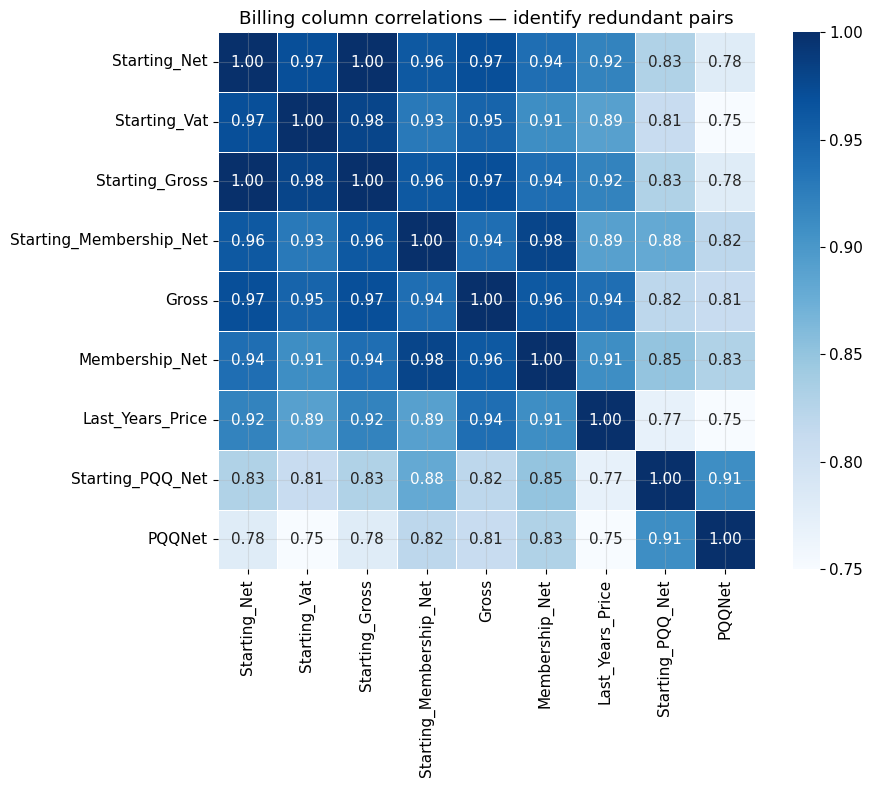

In [209]:
import seaborn as sns

billing_cols = [
    "Starting_Net", "Starting_Vat", "Starting_Gross",
    "Starting_Membership_Net", "Gross", "Membership_Net",
    "Last_Years_Price", "Starting_PQQ_Net", "PQQNet"
]
billing_cols = [c for c in billing_cols if c in df.columns]

plt.figure(figsize=(10, 8))
corr = df[billing_cols].corr().round(2)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, square=True)
plt.title("Billing column correlations — identify redundant pairs")
plt.tight_layout()
plt.show()

In [210]:
# 1. Force numeric conversion first
for col in ['Gross', 'Last_Years_Price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Logic for baseline
has_starting = "Starting_Gross" in df.columns
base_col = "Starting_Gross" if has_starting else "Last_Years_Price"

# 3. Calculate price change
if has_starting:
    df["Starting_Gross"] = pd.to_numeric(df["Starting_Gross"], errors='coerce')
    df["price_change"] = df["Gross"] - df["Starting_Gross"]
else:
    df["price_change"] = df["Gross"] - df["Last_Years_Price"]

# 4. Use np.nan instead of pd.NA to avoid the TypeError
import numpy as np
df["price_increase_pct"] = (
    (df["price_change"] / df[base_col].replace(0, np.nan)) * 100
).round(2)

print("Price features engineered successfully.")

Price features engineered successfully.


In [211]:
print(df[["price_change", "price_increase_pct"]].describe().round(2))

       price_change  price_increase_pct
count     112081.00           112040.00
mean         -48.46               -4.11
std          192.49               11.67
min        -6542.16             -100.00
25%            0.00                0.00
50%            0.00                0.00
75%            0.00                0.00
max        11215.20              514.65


In [212]:
# Group 1: Net/Gross/VAT — all measuring total price paid
# Starting_Gross = Starting_Net + Starting_Vat (mathematically identical)
# Gross ≈ Starting_Gross (0.97 correlation, minimal price change)
# Keep: Last_Years_Price (most interpretable, actual renewal price)
# Keep: Gross (current year actual)
# Drop: Starting_Net, Starting_Vat, Starting_Gross (redundant with Gross)

# Group 2: Membership component
# Starting_Membership_Net vs Membership_Net = 0.98
# Keep: Membership_Net (current), Drop: Starting_Membership_Net

# Group 3: PQQ component  
# Starting_PQQ_Net vs PQQNet = 0.91
# Keep: PQQNet (current), Drop: Starting_PQQ_Net

billing_to_drop = [
    "Starting_Net",            # 1.00 with Starting_Gross
    "Starting_Vat",            # mathematically derived from Starting_Net
    "Starting_Gross",          # = Starting_Net + Starting_Vat
    "Starting_Membership_Net", # 0.98 with Membership_Net
    "Starting_PQQ_Net",        # 0.91 with PQQNet
]

df.drop(columns=[c for c in billing_to_drop if c in df.columns], inplace=True)
print(f"Dropped {len(billing_to_drop)} redundant billing columns")
print(f"Shape after billing drop: {df.shape}")

# What we kept and why
kept_billing = {
    "Last_Years_Price" : "Actual renewal price — most interpretable for churn",
    "Gross"            : "Current year total — captures price changes",
    "Membership_Net"   : "Current membership component",
    "PQQNet"           : "Current PQQ component, includes negative refunds",
    "Package_Net"      : "Package add-on, low correlation with others",
}
print("\nKept billing columns:")
for col, reason in kept_billing.items():
    print(f"  {col:25s} : {reason}")

Dropped 5 redundant billing columns
Shape after billing drop: (112081, 304)

Kept billing columns:
  Last_Years_Price          : Actual renewal price — most interpretable for churn
  Gross                     : Current year total — captures price changes
  Membership_Net            : Current membership component
  PQQNet                    : Current PQQ component, includes negative refunds
  Package_Net               : Package add-on, low correlation with others


In [213]:
df[target] = df[target].map({'Churned': 1, 'Won': 0})

## Univariate-analysis

In [214]:
# ── Style ─────────────────────────────────────────────────────────────────────
BLUE    = "#378ADD"
RED     = "#E24B4A"
GREEN   = "#1D9E75"
AMBER   = "#EF9F27"
PURPLE  = "#7F77DD"
GRAY    = "#888780"
PALETTE = {0: BLUE, 1: RED}
 
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})
 
target = "Prospect_Outcome"

In [215]:
def churn_rate_bar(df, col, title, top_n=None, figsize=(10, 4), rotate=45):
    """Bar chart of churn rate per category, annotated with counts."""
    grp = (
        df.groupby(col)[target]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'churn_rate', 'count': 'n'})
        .sort_values('churn_rate', ascending=False)
        .reset_index()
    )
    if top_n:
        grp = grp.head(top_n)
 
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(grp[col].astype(str), grp['churn_rate'] * 100,
                  color=BLUE, edgecolor='white', alpha=0.85)
 
    # Annotate each bar with n and churn rate
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{row['churn_rate']*100:.1f}%\nn={int(row['n']):,}",
                ha='center', va='bottom', fontsize=9, color=GRAY)
 
    # Overall churn rate reference line
    overall = df[target].mean() * 100
    ax.axhline(overall, color=RED, linestyle='--', linewidth=1.2,
               label=f'Overall churn: {overall:.1f}%')
 
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.legend(fontsize=10)
    plt.xticks(rotation=rotate, ha='right')
    plt.tight_layout()
    plt.show()
    return grp

A1. CHURN RATE BY BAND


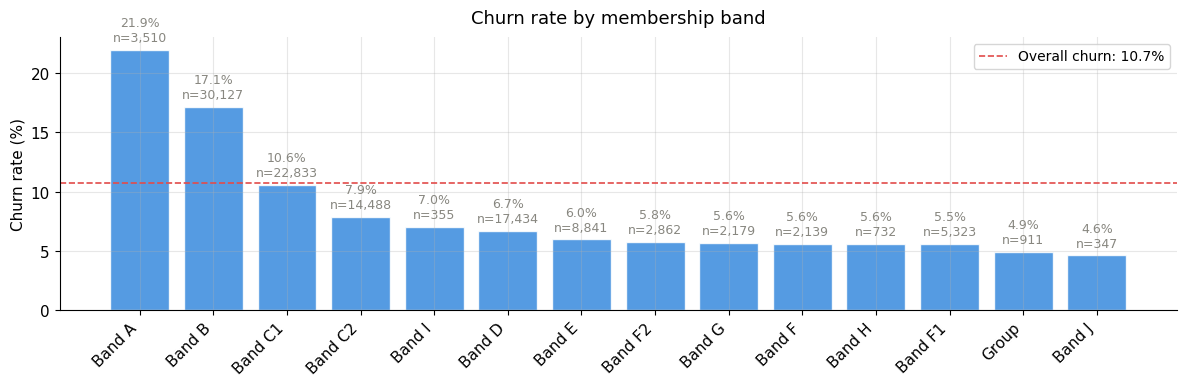

   Band  churn_rate     n
 Band A    0.219373  3510
 Band B    0.171175 30127
Band C1    0.105899 22833
Band C2    0.078686 14488
 Band I    0.070423   355
 Band D    0.066537 17434
 Band E    0.059609  8841
Band F2    0.057652  2862
 Band G    0.056448  2179
 Band F    0.056101  2139
 Band H    0.056011   732
Band F1    0.055420  5323
  Group    0.049396   911
 Band J    0.046110   347


In [216]:
# A1. Churn rate by Band
print("=" * 60)
print("A1. CHURN RATE BY BAND")
print("=" * 60)
band_grp = churn_rate_bar(
    df, 'Band',
    'Churn rate by membership band',
    figsize=(12, 4)
)
print(band_grp.to_string(index=False))


A2. CHURN RATE BY TENURE GROUP


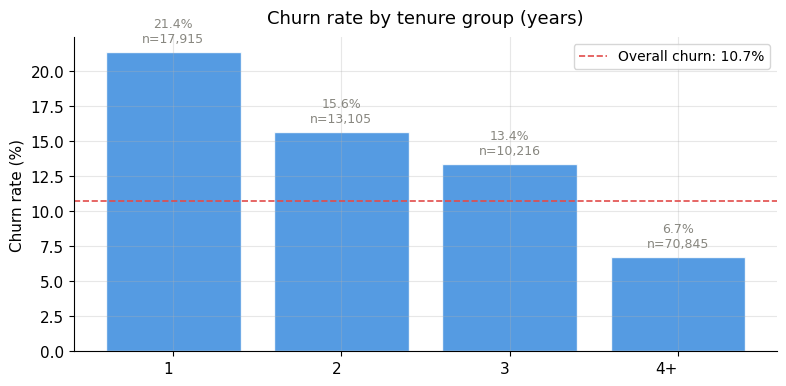

Tenure_Group  churn_rate     n
           1    0.214011 17915
           2    0.156429 13105
           3    0.134005 10216
          4+    0.067034 70845


In [217]:
# A2. Churn rate by Tenure_Group
print("\n" + "=" * 60)
print("A2. CHURN RATE BY TENURE GROUP")
print("=" * 60)
# Ordinal sort
tenure_order = ['1', '2', '3', '4+']
df['Tenure_Group'] = pd.Categorical(
    df['Tenure_Group'].astype(str), categories=tenure_order, ordered=True
)
tenure_grp = churn_rate_bar(
    df, 'Tenure_Group',
    'Churn rate by tenure group (years)',
    figsize=(8, 4), rotate=0
)
print(tenure_grp.to_string(index=False))


A3. CHURN RATE BY MEMBERSHIP STATUS


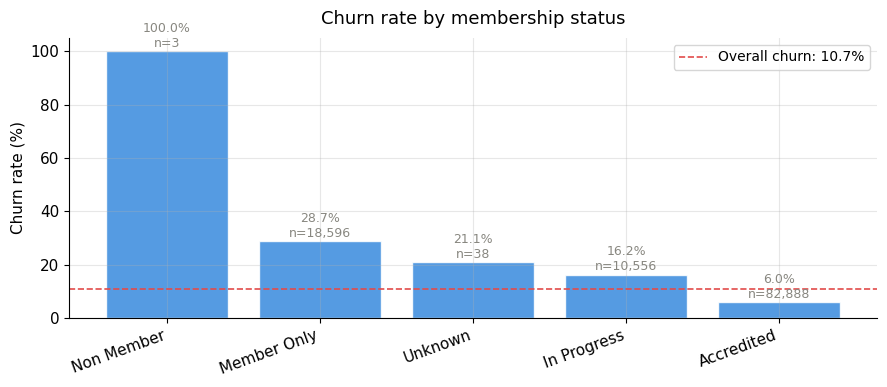

Proforma_Membership_Status  churn_rate     n
                Non Member    1.000000     3
               Member Only    0.286890 18596
                   Unknown    0.210526    38
               In Progress    0.162467 10556
                Accredited    0.059611 82888


In [218]:
# A3. Churn rate by Proforma_Membership_Status
print("\n" + "=" * 60)
print("A3. CHURN RATE BY MEMBERSHIP STATUS")
print("=" * 60)
mem_grp = churn_rate_bar(
    df, 'Proforma_Membership_Status',
    'Churn rate by membership status',
    figsize=(9, 4), rotate=20
)
print(mem_grp.to_string(index=False))


A4. CHURN RATE BY AUDIT STATUS GROUP


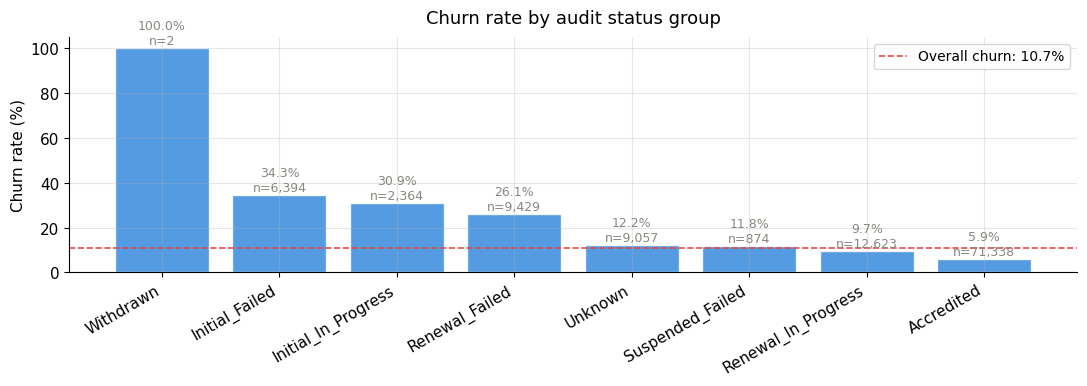

 Audit_Status_Group  churn_rate     n
          Withdrawn    1.000000     2
     Initial_Failed    0.342821  6394
Initial_In_Progress    0.308799  2364
     Renewal_Failed    0.260791  9429
            Unknown    0.122226  9057
   Suspended_Failed    0.117849   874
Renewal_In_Progress    0.096887 12623
         Accredited    0.058678 71338


In [219]:
# A4. Churn rate by Audit_Status_Group
print("\n" + "=" * 60)
print("A4. CHURN RATE BY AUDIT STATUS GROUP")
print("=" * 60)
audit_grp = churn_rate_bar(
    df, 'Audit_Status_Group',
    'Churn rate by audit status group',
    figsize=(11, 4), rotate=30
)
print(audit_grp.to_string(index=False))


A5. CHURN RATE BY PROSPECT STATUS GROUP


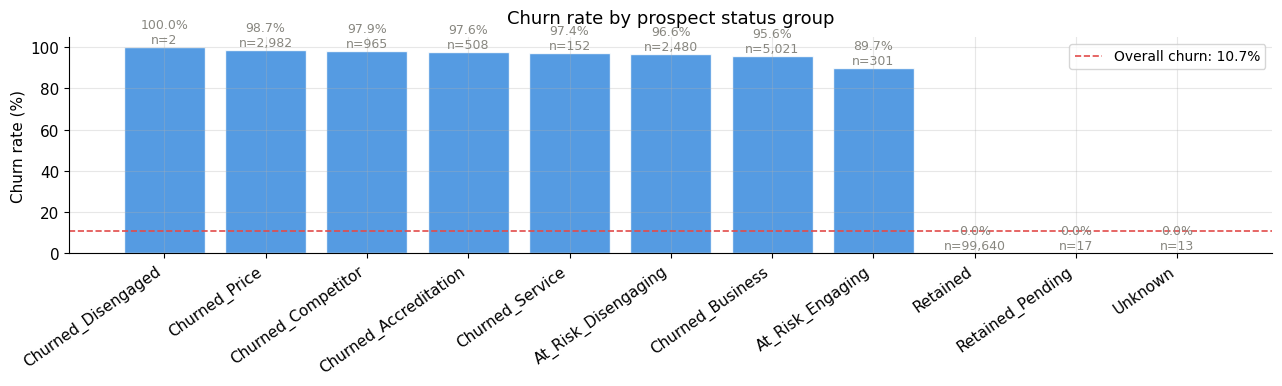

Prospect_Status_Group  churn_rate     n
   Churned_Disengaged    1.000000     2
        Churned_Price    0.986922  2982
   Churned_Competitor    0.979275   965
Churned_Accreditation    0.976378   508
      Churned_Service    0.973684   152
  At_Risk_Disengaging    0.965726  2480
     Churned_Business    0.956383  5021
     At_Risk_Engaging    0.897010   301
             Retained    0.000010 99640
     Retained_Pending    0.000000    17
              Unknown    0.000000    13


In [220]:
# A5. Churn rate by Prospect_Status_Group
print("\n" + "=" * 60)
print("A5. CHURN RATE BY PROSPECT STATUS GROUP")
print("=" * 60)
status_grp = churn_rate_bar(
    df, 'Prospect_Status_Group',
    'Churn rate by prospect status group',
    figsize=(13, 4), rotate=35
)
print(status_grp.to_string(index=False))

In [221]:
df.drop(columns=['Prospect_Status_Group'], inplace=True)
print("Dropped Prospect_Status_Group — label proxy, causes leakage")

Dropped Prospect_Status_Group — label proxy, causes leakage



A6. CHURN RATE BY PAYMENT METHOD


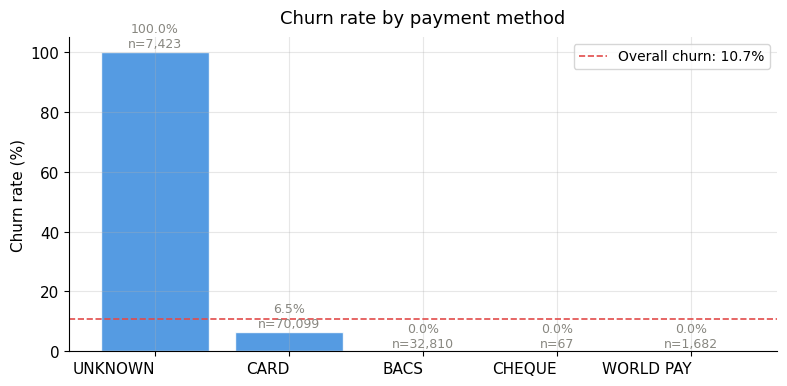

Payment_Method  churn_rate     n
       UNKNOWN    1.000000  7423
          CARD    0.065322 70099
          BACS    0.000000 32810
        CHEQUE    0.000000    67
     WORLD PAY    0.000000  1682


In [222]:
# A6. Churn rate by Payment_Method
print("\n" + "=" * 60)
print("A6. CHURN RATE BY PAYMENT METHOD")
print("=" * 60)
pay_grp = churn_rate_bar(
    df, 'Payment_Method',
    'Churn rate by payment method',
    figsize=(8, 4), rotate=0
)
print(pay_grp.to_string(index=False))

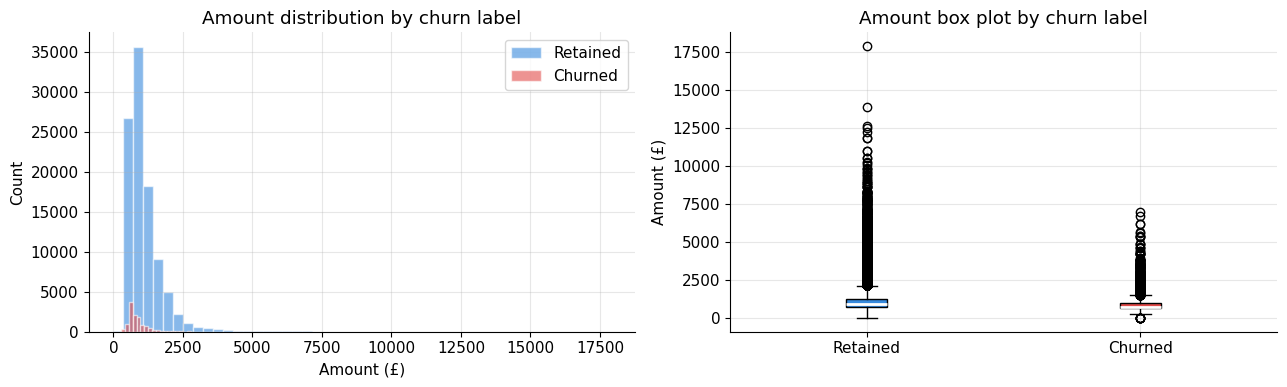

In [223]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
for label, color, name in [(0, BLUE, 'Retained'), (1, RED, 'Churned')]:
    data = df[df[target] == label]['Amount'].dropna()
    axes[0].hist(data, bins=50, alpha=0.6, color=color,
                 label=name, edgecolor='white')

axes[0].set_title('Amount distribution by churn label')
axes[0].set_xlabel('Amount (£)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
bp_data = [
    df[df[target] == 0]['Amount'].dropna(),
    df[df[target] == 1]['Amount'].dropna()
]
bp = axes[1].boxplot(bp_data, patch_artist=True,
                     labels=['Retained', 'Churned'],
                     medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(BLUE)
bp['boxes'][1].set_facecolor(RED)
axes[1].set_title('Amount box plot by churn label')
axes[1].set_ylabel('Amount (£)')

plt.tight_layout()
plt.show()  # only ONE plt.show() at the end, not inside any loop

## Bivariate Analysis

In [224]:
def bivariate_box(df, col, title, xlabel):
    """Box plot + mean annotation for a continuous variable vs churn."""
    fig, ax = plt.subplots(figsize=(7, 4))
    bp_data = [
        df[df[target] == 0][col].dropna(),
        df[df[target] == 1][col].dropna()
    ]
    bp = ax.boxplot(bp_data, patch_artist=True,
                    labels=['Retained', 'Churned'],
                    medianprops=dict(color='white', linewidth=2),
                    showfliers=False)  # hide extreme outliers for clarity
    bp['boxes'][0].set_facecolor(BLUE)
    bp['boxes'][1].set_facecolor(RED)
 
    # Annotate means
    for i, (data, name) in enumerate(zip(bp_data, ['Retained', 'Churned']), 1):
        mean_val = data.mean()
        ax.text(i, mean_val, f'  μ={mean_val:.2f}',
                va='center', fontsize=9, color=GRAY)
 
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(xlabel)
    plt.tight_layout()
    plt.show()
 
    for label, name in [(0, 'Retained'), (1, 'Churned')]:
        d = df[df[target] == label][col].dropna()
        print(f"  {name}: mean={d.mean():.3f}  median={d.median():.3f}  n={len(d):,}")


B1. PRICE CHANGE VS CHURN


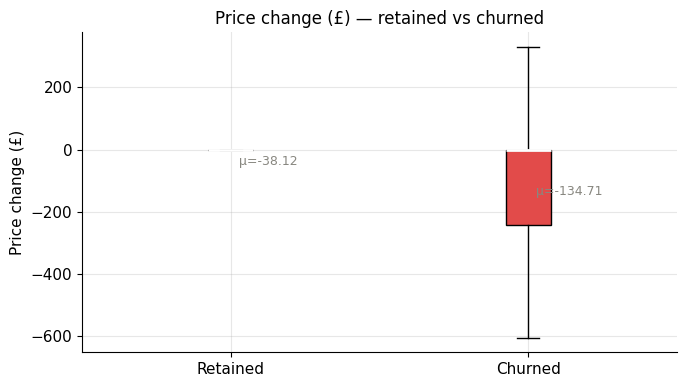

  Retained: mean=-38.116  median=0.000  n=100,079
  Churned: mean=-134.713  median=0.000  n=12,002


In [225]:
# B1. Price change vs churn
print("\n" + "=" * 60)
print("B1. PRICE CHANGE VS CHURN")
print("=" * 60)
if 'price_change' in df.columns:
    bivariate_box(df, 'price_change',
                  'Price change (£) — retained vs churned',
                  'Price change (£)')


B2. PAYMENT TIMEFRAME VS CHURN


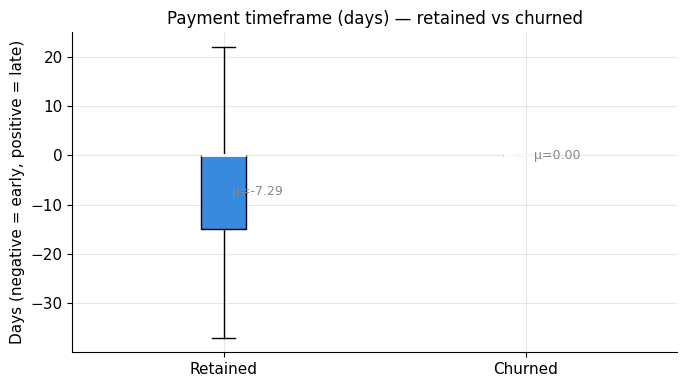

  Retained: mean=-7.292  median=0.000  n=100,079
  Churned: mean=0.000  median=0.000  n=12,002


In [226]:
# B2. Payment_Timeframe vs churn
print("\n" + "=" * 60)
print("B2. PAYMENT TIMEFRAME VS CHURN")
print("=" * 60)
bivariate_box(df, 'Payment_Timeframe',
              'Payment timeframe (days) — retained vs churned',
              'Days (negative = early, positive = late)')


B3. CURRENT ANCHORINGS VS CHURN


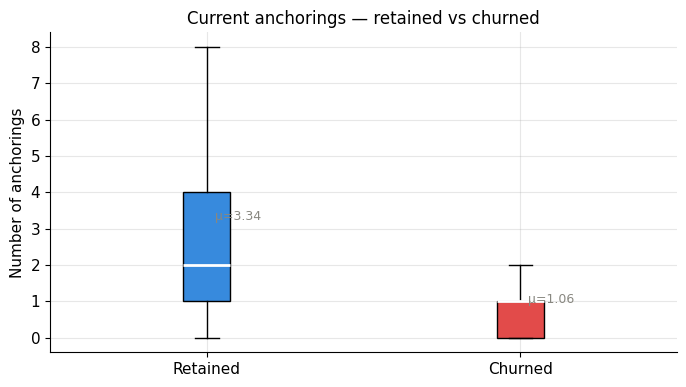

  Retained: mean=3.340  median=2.000  n=100,079
  Churned: mean=1.059  median=1.000  n=12,002


In [227]:
# B3. Current_Anchorings vs churn
print("\n" + "=" * 60)
print("B3. CURRENT ANCHORINGS VS CHURN")
print("=" * 60)
bivariate_box(df, 'Current_Anchorings',
              'Current anchorings — retained vs churned',
              'Number of anchorings')


B5. RENEWAL CALL COUNT VS CHURN


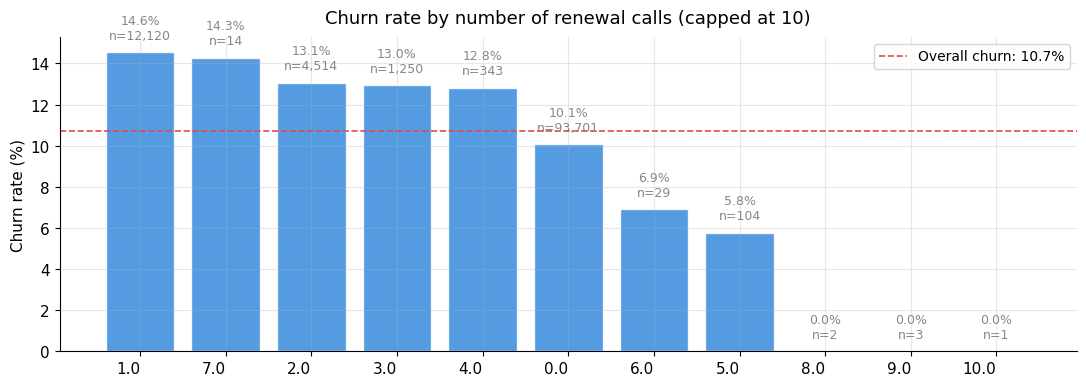

In [228]:
print("\n" + "=" * 60)
print("B5. RENEWAL CALL COUNT VS CHURN")
print("=" * 60)
if 'rc_total_calls' in df.columns:
    # Cap at 10 for readability
    df['rc_calls_capped'] = df['rc_total_calls'].clip(upper=10)
    calls_grp = churn_rate_bar(
        df, 'rc_calls_capped',
        'Churn rate by number of renewal calls (capped at 10)',
        figsize=(11, 4), rotate=0
    )
    df.drop(columns=['rc_calls_capped'], inplace=True)


B6. CC CONTRACTOR SUGGEST LEAVE VS CHURN


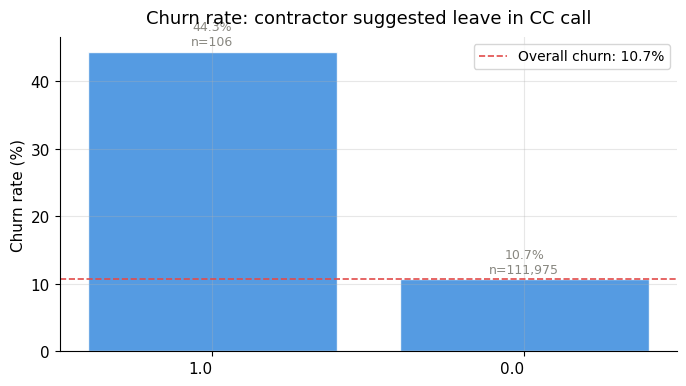

In [229]:
print("\n" + "=" * 60)
print("B6. CC CONTRACTOR SUGGEST LEAVE VS CHURN")
print("=" * 60)
cc_leave_col = next(
    (c for c in df.columns if 'contractor_suggest_leave' in c.lower()), None
)
if cc_leave_col:
    churn_rate_bar(
        df, cc_leave_col,
        'Churn rate: contractor suggested leave in CC call',
        figsize=(7, 4), rotate=0
    )


B7. FINANCIAL HARDSHIP MENTIONED (CRM) VS CHURN


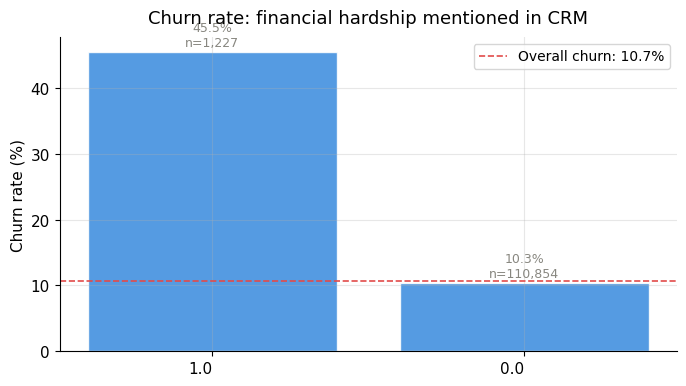

In [230]:
print("\n" + "=" * 60)
print("B7. FINANCIAL HARDSHIP MENTIONED (CRM) VS CHURN")
print("=" * 60)
if 'crm_financial_hardship_mentioned' in df.columns:
    churn_rate_bar(
        df, 'crm_financial_hardship_mentioned',
        'Churn rate: financial hardship mentioned in CRM',
        figsize=(7, 4), rotate=0
    )

## Multi-variate Analysis

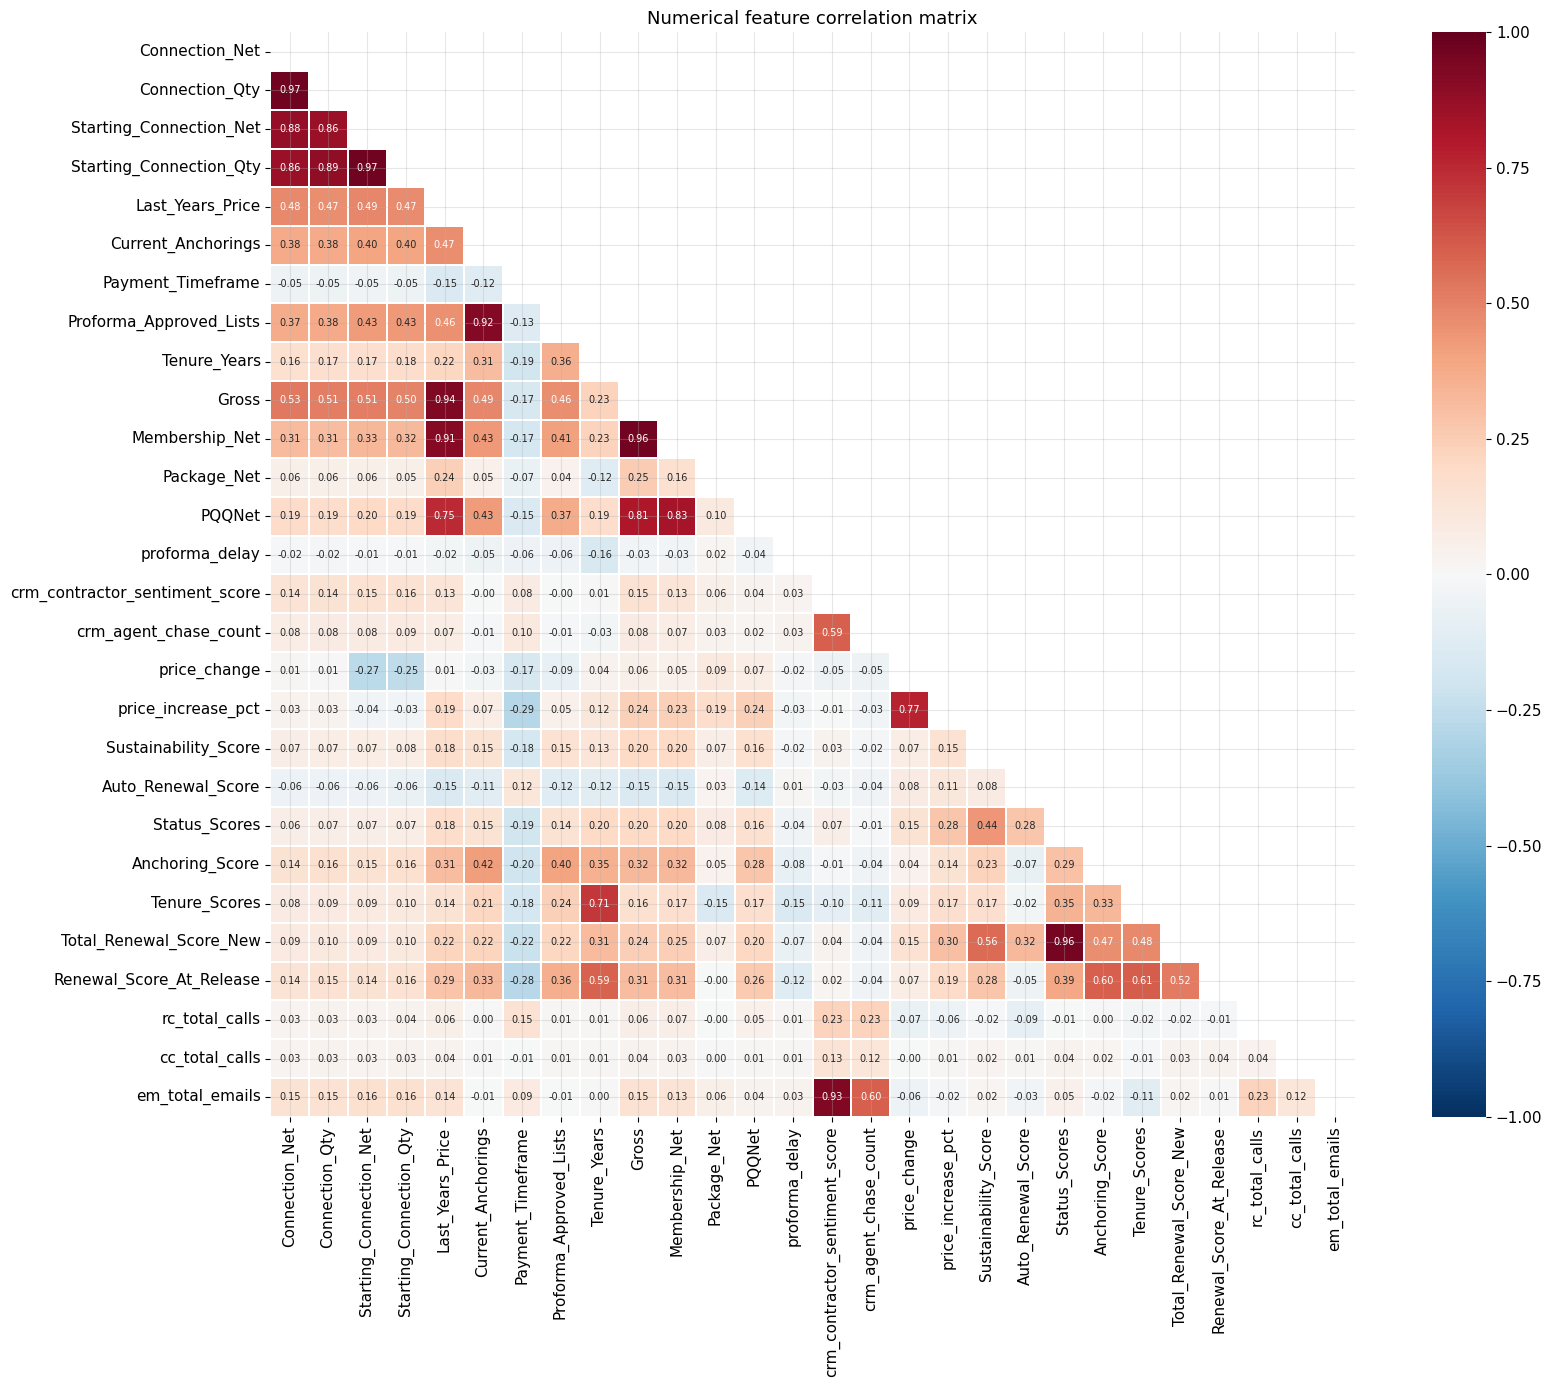


Highly correlated pairs (|r| > 0.85):
                         col_a                   col_b     r
       Starting_Connection_Net Starting_Connection_Qty 0.975
                Connection_Net          Connection_Qty 0.974
                         Gross          Membership_Net 0.965
                 Status_Scores Total_Renewal_Score_New 0.958
              Last_Years_Price                   Gross 0.937
crm_contractor_sentiment_score         em_total_emails 0.926
            Current_Anchorings Proforma_Approved_Lists 0.919
              Last_Years_Price          Membership_Net 0.911
                Connection_Qty Starting_Connection_Qty 0.890
                Connection_Net Starting_Connection_Net 0.881
                Connection_Net Starting_Connection_Qty 0.864
                Connection_Qty Starting_Connection_Net 0.861

Numerical features ranked by correlation with churn_label:
                 feature       r   p
 Total_Renewal_Score_New -0.6738 0.0
           Status_Scores -0.6696 0

In [231]:
# =============================================================
# MULTIVARIATE ANALYSIS
# =============================================================

import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats as scipy_stats 

# ── 1. Numerical correlation heatmap ─────────────────────────
num_cols = [
    'Connection_Net', 'Connection_Qty', 'Starting_Connection_Net',
    'Starting_Connection_Qty', 'Last_Years_Price', 'Current_Anchorings',
    'Payment_Timeframe', 'Proforma_Approved_Lists', 'Tenure_Years',
    'Gross', 'Membership_Net', 'Package_Net', 'PQQNet',
    'proforma_delay', 'crm_contractor_sentiment_score',
    'crm_agent_chase_count', 'price_change', 'price_increase_pct',
    'Sustainability_Score', 'Auto_Renewal_Score', 'Status_Scores',
    'Anchoring_Score', 'Tenure_Scores', 'Total_Renewal_Score_New',
    'Renewal_Score_At_Release', 'rc_total_calls', 'cc_total_calls',
    'em_total_emails',
]
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, square=True,
    annot_kws={'size': 7}
)
plt.title('Numerical feature correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.85):")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append({
                'col_a': corr.columns[i],
                'col_b': corr.columns[j],
                'r': round(r, 3)
            })
high_corr_df = pd.DataFrame(high_corr).sort_values('r', ascending=False)
print(high_corr_df.to_string(index=False))

# ── 2. Feature vs target — point biserial for numerics ───────
print("\nNumerical features ranked by correlation with churn_label:")
pb_corrs = []
for col in num_cols:
    r, p = scipy_stats.pointbiserialr(df[target], df[col].fillna(0))
    pb_corrs.append({'feature': col, 'r': round(r, 4), 'p': round(p, 6)})

pb_df = (pd.DataFrame(pb_corrs)
         .sort_values('r', key=abs, ascending=False)
         .reset_index(drop=True))
print(pb_df.head(20).to_string(index=False))

# ── 3. Categorical features — Cramer's V vs churn_label ──────
cat_cols = [
    'Band', 'Tenure_Group', 'Proforma_Membership_Status',
    'Audit_Status_Group', 'Payment_Method', 'Proforma_Account_Stage',
    'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
    'Connection_Group', 'Anchor_Group', 'Last_Band',
]
cat_cols = [c for c in cat_cols if c in df.columns]

print("\nCategorical features ranked by Cramer's V with churn_label:")
cramer_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col].astype(str).fillna('Missing'), df['churn_label'])
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    min_dim = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    cramer_results.append({'feature': col, "cramer_v": round(v, 4)})

cramer_df = (pd.DataFrame(cramer_results)
             .sort_values('cramer_v', ascending=False)
             .reset_index(drop=True))
print(cramer_df.to_string(index=False))

In [232]:
drop_correlated = [
    # Connection group — keep Connection_Qty only
    'Connection_Net',
    'Starting_Connection_Net',
    'Starting_Connection_Qty',

    # Billing group — keep Gross, price_change, price_increase_pct
    'Last_Years_Price',
    'Membership_Net',

    # Renewal score group — keep Total_Renewal_Score_New
    'Status_Scores',

    # Anchoring group — keep Current_Anchorings
    'Proforma_Approved_Lists',

    # CRM — keep crm_contractor_sentiment_score
    'em_total_emails',
]

drop_correlated = [c for c in drop_correlated if c in df.columns]
df.drop(columns=drop_correlated, inplace=True)
print(f"Dropped {len(drop_correlated)} correlated columns")
print(f"Shape: {df.shape}")

Dropped 8 correlated columns
Shape: (112081, 295)


NO_interaction handling

In [233]:
rc_cols = [col for col in df.columns if col.startswith('rc_')]
cc_cols = [col for col in df.columns if col.startswith('cc_')]
em_cols = [col for col in df.columns if col.startswith('em_')]

In [234]:
# Check unique values per group to understand the full picture
for prefix, cols in [("rc_", rc_cols), ("cc_", cc_cols), ("em_", em_cols)]:
    all_unique = set()
    tri_state_cols  = []
    binary_cols     = []
    numeric_cols    = []
    
    for col in cols:
        unique_vals = set(df[col].dropna().unique())
        all_unique.update(unique_vals)
        
        if "No_Interaction" in unique_vals:
            tri_state_cols.append(col)
        elif df[col].dtype == object:
            binary_cols.append(col)
        else:
            numeric_cols.append(col)
    
    print(f"\n{prefix} group ({len(cols)} cols)")
    print(f"  All unique values seen : {all_unique}")
    print(f"  Tri-state cols         : {len(tri_state_cols)}")
    print(f"  Other object cols      : {len(binary_cols)}")
    print(f"  Already numeric        : {len(numeric_cols)}")
    
def encode_tri_state(df, cols, prefix):
    """
    No_Interaction → had_interaction=0, is_true=0
    False          → had_interaction=1, is_true=0  
    True           → had_interaction=1, is_true=1
    """
    tri_state_cols = [
        c for c in cols 
        if "No_Interaction" in set(df[c].dropna().unique())
    ]
    other_obj_cols = [
        c for c in cols 
        if df[c].dtype == object and c not in tri_state_cols
    ]
    
    print(f"\n{prefix} — encoding {len(tri_state_cols)} tri-state cols")
    print(f"{prefix} — other object cols to inspect: {other_obj_cols}")
    
    for col in tri_state_cols:
        # Flag 1: did any interaction happen at all?
        df[f"{col}_interacted"] = (df[col] != "No_Interaction").astype(int)
        
        # Flag 2: was the value True (positive signal)?
        df[f"{col}_true"]       = (df[col] == "True").astype(int)
        
        # Drop original
        df.drop(columns=[col], inplace=True)
    
    return df, tri_state_cols

# Apply to all three groups
df, rc_tristate = encode_tri_state(df, rc_cols, "rc_")
df, cc_tristate = encode_tri_state(df, cc_cols, "cc_")
df, em_tristate = encode_tri_state(df, em_cols, "em_")

total_original = len(rc_tristate) + len(cc_tristate) + len(em_tristate)
total_new      = total_original * 2  # each becomes 2 columns

print(f"\nOriginal tri-state cols  : {total_original}")
print(f"New encoded cols         : {total_new}")
print(f"Net change               : +{total_new - total_original} cols")
print(f"Shape after encoding     : {df.shape}")


rc_ group (201 cols)
  All unique values seen : {np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), 'No_Interaction', 'Negative', 'Neutral', 'Not Mentioned', 'Positive', 'Better Value', 'True', 'Similar Value', 'No Comparison', 'Inbound', 'False', 'Outbound'}
  Tri-state cols         : 187
  Other object cols      : 0
  Already numeric        : 14

cc_ group (20 cols)
  All unique values seen : {np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(6.0), np.float64(7.0), np.float64(10.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), 'True', np.float64(35.0), np.float64(40.0), np.float64(42.5), np.float64(43.333333333333336), np.float64(45.0), np.float64(50.0), np.float64(52.5), np.float64(53.333333333333336), np.float64(55.0), np.float64(56.66666666666666), np.float64(57.5), np.float64(60.0), np.floa

In [235]:
# Create one master interaction flag per group
df["had_rc_interaction"] = (
    df[[c for c in df.columns if c.startswith("rc_")]]
    .sum(axis=1) > 0
).astype(int)

df["had_cc_interaction"] = (
    df[[c for c in df.columns if c.startswith("cc_")]]
    .sum(axis=1) > 0
).astype(int)

df["had_em_interaction"] = (
    df[[c for c in df.columns if c.startswith("em_")]]
    .sum(axis=1) > 0
).astype(int)

# Now drop all individual _interacted flags — replaced by the master flags
interacted_cols = [c for c in df.columns if c.endswith("_interacted")]
df.drop(columns=interacted_cols, inplace=True)

print(f"Dropped {len(interacted_cols)} individual _interacted flags")
print(f"Kept 3 master flags: had_rc_interaction, had_cc_interaction, had_em_interaction")
print(f"Shape: {df.shape}")

Dropped 198 individual _interacted flags
Kept 3 master flags: had_rc_interaction, had_cc_interaction, had_em_interaction
Shape: (112081, 298)


In [236]:
print("RC interacted cols:", [c for c in df.columns if c.startswith("rc_") and c.endswith("_interacted")][:5])
print("Total interacted cols:", len([c for c in df.columns if c.endswith("_interacted")]))

RC interacted cols: []
Total interacted cols: 0


In [237]:
# Sanity check — spot check a few columns
sample_rc = [c for c in df.columns if c.startswith("rc_") and c.endswith("_true")][:3]
sample_cc = [c for c in df.columns if c.startswith("cc_") and c.endswith("_true")][:3]
sample_em = [c for c in df.columns if c.startswith("em_") and c.endswith("_true")][:3]

check_cols = sample_rc + sample_cc + sample_em + [
    "had_rc_interaction", "had_cc_interaction", "had_em_interaction"
]
print("\nSample of encoded columns:")
print(df[check_cols].head(10))
print("\nValue counts for had_rc_interaction:")
print(df["had_rc_interaction"].value_counts())
print("\nValue counts for had_em_interaction:")
print(df["had_em_interaction"].value_counts())


Sample of encoded columns:
   rc_call_direction_true  rc_customer_response_true  \
0                       0                          0   
1                       0                          0   
2                       0                          0   
3                       0                          0   
4                       0                          0   
5                       0                          0   
6                       0                          0   
7                       0                          0   
8                       0                          0   
9                       0                          0   

   rc_competitor_value_comparison_true  cc_call_initiated_by_true  \
0                                    0                          0   
1                                    0                          0   
2                                    0                          0   
3                                    0                          0   
4         

In [273]:
df["Prospect_Outcome"].value_counts()

Prospect_Outcome
0    100079
1     12002
Name: count, dtype: int64

In [287]:
target = (df["Prospect_Outcome"] == "Churned").astype(int)

rc_cols = [col for col in df.columns if col.startswith('rc_')]
cc_cols = [col for col in df.columns if col.startswith('cc_')]
em_cols = [col for col in df.columns if col.startswith('em_')]

all_cols = rc_cols + cc_cols + em_cols

df[all_cols] = df[all_cols].apply(pd.to_numeric, errors="coerce").fillna(0)


In [290]:
overall_churn = df['Prospect_Outcome'].mean()
print(f"Overall churn rate: {overall_churn:.4f}")

Overall churn rate: 0.1071


In [292]:
results = []

for col in all_cols:
    
    support = df[col].sum()
    
    # skip useless columns
    if support < 50:
        continue
    
    # churn when feature present
    churn_rate = df.loc[df[col] > 0, 'Prospect_Outcome'].mean()
    
    # lift
    lift = churn_rate / overall_churn if overall_churn > 0 else 0
    
    results.append({
        "column": col,
        "support": int(support),
        "churn_rate_when_1": round(churn_rate, 4),
        "lift": round(lift, 3)
    })

result_df = pd.DataFrame(results)

In [293]:
result_df = result_df.sort_values("lift", ascending=False).reset_index(drop=True)

print("\nTOP FEATURES:")
display(result_df.head(20))

print("\nLOW SIGNAL FEATURES (lift ~ 1):")
display(result_df[result_df["lift"] < 1.05].head(20))


TOP FEATURES:


,column,support,churn_rate_when_1,lift
0,rc_churn_cat_switch___change___alternate_provi...,76,0.7632,7.127
1,rc_reaction_cat_cancellation_true,71,0.7465,6.971
2,rc_churn_cat_left___not_with_client_anymore_true,197,0.7411,6.921
3,rc_agent_response_cat_cancellation___terminati...,794,0.7254,6.775
4,rc_churn_cat_financial_struggles___business_pr...,219,0.7032,6.567
5,rc_churn_cat_unnecessary___not_needed_true,401,0.7007,6.544
6,rc_churn_cat_lack_of_benefits_true,134,0.6567,6.133
7,rc_Membership_Renewal_Decision,1954,0.6433,6.007
8,rc_response_cat_cancellation___termination___n...,779,0.6418,5.994
9,rc_churn_cat_customer_service___support_true,56,0.6250,5.837



LOW SIGNAL FEATURES (lift ~ 1):


,column,support,churn_rate_when_1,lift
84,rc_reaction_cat_negotiation_true,116,0.1121,1.047
85,rc_justification_cat_discount_removal___vat_in...,286,0.1119,1.045
86,rc_renewal_reason_cat_discounts___incentives_true,201,0.1095,1.022
87,rc_justification_cat_pricing_adjustments_decre...,64,0.1094,1.021
88,rc_agent_response_cat_price_and_cost_true,395,0.1063,0.993
89,rc_pitch_cat_payment_and_billings___invoice_true,3061,0.1058,0.988
90,rc_justification_cat_change_in_package_true,153,0.1046,0.977
91,rc_reaction_cat_discount___offer_true,118,0.1017,0.950
92,rc_agent_response_cat_auto___automatic_true,295,0.1017,0.950
93,rc_complaint_cat_discounts_true,70,0.1000,0.934


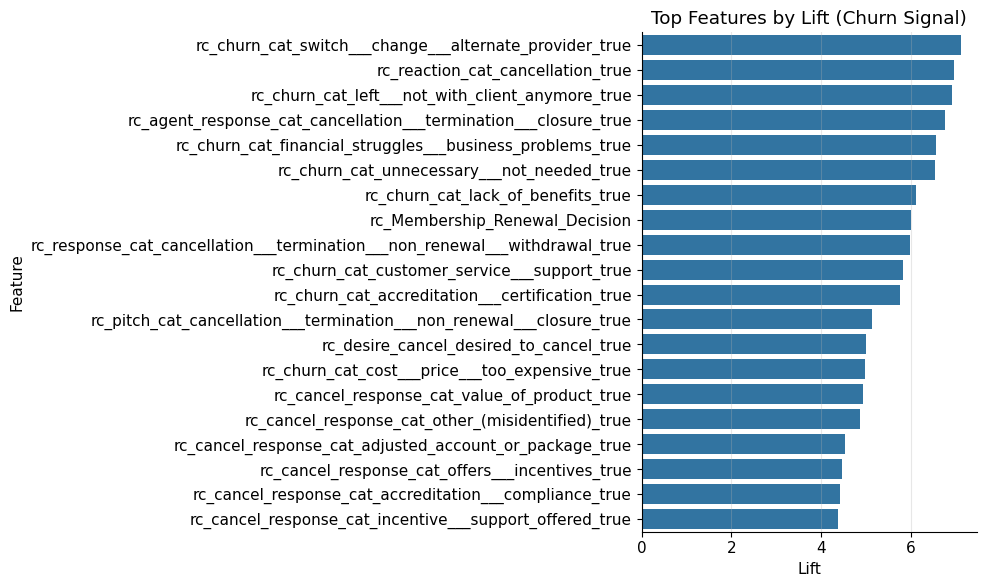

In [294]:
top = result_df.head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top, x="lift", y="column")
plt.title("Top Features by Lift (Churn Signal)")
plt.xlabel("Lift")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [295]:
selected_cols = result_df[result_df["lift"] > 1.2]["column"].tolist()

print(f"\nSelected features count: {len(selected_cols)}")


Selected features count: 79


In [300]:
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)

rc_cols = [c for c in df.columns if c.startswith("rc_")]
cc_cols = [c for c in df.columns if c.startswith("cc_")]
em_cols = [c for c in df.columns if c.startswith("em_")]

all_signal_cols = rc_cols + cc_cols + em_cols

#  REMOVE ALL SIGNAL COLS
df_base = df.drop(columns=all_signal_cols, errors="ignore")

# Define thresholds
high_signal_cols = result_df[result_df["lift"] >= 2]["column"].tolist()
medium_signal_cols = result_df[
    (result_df["lift"] >= 1.2) & (result_df["lift"] < 2)
]["column"].tolist()

selected_signal_cols = high_signal_cols + medium_signal_cols

# Add them back
df_feature = df_base.copy()
df_feature[selected_signal_cols] = df[selected_signal_cols]

df_feature.shape

(112081, 150)

## HYPOTHESIS TESTING

In [301]:
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

# ================================
# 1. PREP
# ================================
df_ht = df_feature.copy()

target_col = "target"

# Separate feature types
categorical_cols = [c for c in df_ht.columns if df_ht[c].nunique() <= 2 and c != target_col]
continuous_cols = [c for c in df_ht.columns if df_ht[c].nunique() > 2 and c != target_col]

print("Categorical:", len(categorical_cols))
print("Continuous:", len(continuous_cols))

Categorical: 107
Continuous: 42


In [ ]:
cat_results = []

# Use the 'target' variable you defined earlier
target_var = target if 'Prospect_Outcome' in locals() else 'Prospect_Outcome'

for col in categorical_cols:
    try:
        # 1. Create the contingency table
        contingency = pd.crosstab(df[col], df[target_var])

        # 2. Check if the table is valid for a test (needs at least 2 rows and 2 cols)
        if contingency.size < 4: 
            continue

        # 3. Run the test
        from scipy.stats import chi2_contingency
        chi2, p, dof, _ = chi2_contingency(contingency)

        # 4. Effect size (Cramer's V) - more robust calculation for non-2x2 tables
        n = contingency.sum().sum()
        min_dim = min(contingency.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

        cat_results.append({
            "column": col,
            "test": "chi2",
            "p_value": p,
            "cramers_v": cramers_v,
            "significant": p < 0.05
        })

    except Exception as e:
        # This tells you WHICH column failed and WHY
        print(f"Error in column {col}: {e}")
        continue

# Final Check
if not cat_results:
    print("CRITICAL: No results were generated. Check your categorical_cols list and target variable.")
else:
    cat_results_df = pd.DataFrame(cat_results).sort_values("p_value")
    print("\nTop categorical signals:")
    display(cat_results_df.head(20))


Top categorical signals:


,column,test,p_value,cramers_v,significant
0,Auto_Renewal_Score,chi2,0.000000e+00,0.235470,True
3,Current_Auto_Renewal_Flag,chi2,0.000000e+00,0.146508,True
5,Prospect_Outcome,chi2,0.000000e+00,0.999953,True
4,Current_World_Pay_Token,chi2,0.000000e+00,0.235460,True
6,churn_label,chi2,0.000000e+00,0.999953,True
7,is_new_customer,chi2,0.000000e+00,0.177564,True
12,crm_contractor_suggested_leave,chi2,0.000000e+00,0.226573,True
8,payment_timeframe_missing,chi2,0.000000e+00,0.999953,True
25,crm_financial_hardship_mentioned,chi2,0.000000e+00,0.118156,True
23,crm_negative_customer_experience,chi2,0.000000e+00,0.120503,True


In [306]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

cont_results = []

# Ensure these are the correct STRING names
target_name = "Prospect_Outcome" 
# Use the main dataframe if df_ht isn't defined or is filtered too strictly
df_to_test = df 

for col in continuous_cols:
    try:
        # 1. Selection logic using the string name
        group1 = df_to_test[df_to_test[target_name] == 1][col].dropna()
        group0 = df_to_test[df_to_test[target_name] == 0][col].dropna()

        # 2. Check for sufficient data and variance
        if len(group1) < 20 or len(group0) < 20:
            continue
        if group1.nunique() <= 1 and group0.nunique() <= 1:
            continue

        # 3. Perform T-Test (Welch's T-test with equal_var=False)
        t_stat, p = ttest_ind(group1, group0, equal_var=False)

        # 4. Cohen's d (Effect Size)
        # Using a more robust pooled standard deviation formula
        n1, n2 = len(group1), len(group0)
        var1, var2 = group1.var(), group0.var()
        pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
        
        cohens_d = (group1.mean() - group0.mean()) / pooled_std if pooled_std != 0 else 0

        cont_results.append({
            "column": col,
            "p_value": p,
            "cohens_d": cohens_d,
            "significant": p < 0.05
        })

    except Exception as e:
        print(f"Skipping {col} due to error: {e}")
        continue

# Final execution and display
if not cont_results:
    print("No continuous results found. Check column names and target variable.")
else:
    cont_results_df = pd.DataFrame(cont_results).sort_values("p_value")
    print(f"Successfully analyzed {len(cont_results_df)} continuous features.")
    display(cont_results_df.head(20))

Skipping Discount_Amount due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Proforma_Account_Stage due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Proforma_Audit_Status due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Proforma_Membership_Status due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Band due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Prospect_Status due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Payment_Method due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Connection_Group due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Tenure_Group due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Last_Renewal due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping Last_Band due to error: unsupported operand type(s) for /: 'str' and 'int'
Skipping 

,column,p_value,cohens_d,significant
1,Sustainability_Score,0.000000e+00,-1.016623,True
2,Total_Renewal_Score_New,0.000000e+00,-2.948601,True
3,Anchoring_Score,0.000000e+00,-0.737222,True
4,Tenure_Scores,0.000000e+00,-1.337687,True
6,Payment_Timeframe,0.000000e+00,0.289029,True
5,Current_Anchorings,0.000000e+00,-0.353573,True
7,Renewal_Score_At_Release,0.000000e+00,-1.095063,True
8,Tenure_Years,0.000000e+00,-0.548399,True
14,Amount,0.000000e+00,-0.336168,True
10,Gross,0.000000e+00,-0.472621,True


In [311]:
# Strong categorical features
strong_cat = cat_results_df[
    (cat_results_df["p_value"] < 0.05) & (cat_results_df["cramers_v"] > 0.05)
]

# Strong continuous features (FIXED: use cohens_d instead of effect_size)
strong_cont = cont_results_df[
    (cont_results_df["p_value"] < 0.05) & (abs(cont_results_df["cohens_d"]) > 0.2)
]

print("Strong categorical features:", len(strong_cat))
print("Strong continuous features:", len(strong_cont))

Strong categorical features: 34
Strong continuous features: 21


In [313]:
strong_cat_cols = strong_cat["column"].tolist()
strong_cont_cols = strong_cont["column"].tolist()

print("Categorical:", strong_cat_cols)
print("Continuous:", strong_cont_cols)

Categorical: ['Auto_Renewal_Score', 'Current_Auto_Renewal_Flag', 'Prospect_Outcome', 'Current_World_Pay_Token', 'churn_label', 'is_new_customer', 'crm_contractor_suggested_leave', 'payment_timeframe_missing', 'crm_financial_hardship_mentioned', 'crm_negative_customer_experience', 'rc_churn_cat_unnecessary___not_needed_true', 'rc_desire_cancel_desired_to_cancel_true', 'rc_Membership_Renewal_Decision', 'rc_response_cat_cancellation___termination___non_renewal___withdrawal_true', 'rc_agent_response_cat_cancellation___termination___closure_true', 'em_sentiment_dissatisfied_true', 'rc_Renewal_Impact_Due_to_Price_Increase', 'rc_churn_cat_left___not_with_client_anymore_true', 'rc_churn_cat_financial_struggles___business_problems_true', 'rc_pitch_cat_cancellation___termination___non_renewal___closure_true', 'rc_churn_cat_cost___price___too_expensive_true', 'crm_membership_overdue', 'crm_customer_complained', 'rc_churn_cat_lack_of_benefits_true', 'rc_cancel_response_cat_incentive___support_offe

In [315]:
# Selected important features
selected_set = set(strong_cat_cols + strong_cont_cols)

# Remove only unwanted rc/cc/em features
cols_to_remove = [
    col for col in df.columns
    if col.startswith(("rc_", "cc_", "em_")) and col not in selected_set
]

df_final = df.drop(columns=cols_to_remove)

print("Final shape:", df_final.shape)

Final shape: (112081, 89)


In [316]:
display(df_final.columns)

Index(['Connection_Qty', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Auto_Renewal_Score', 'Anchoring_Score',
       'Tenure_Scores', 'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Payment_Timeframe', 'Proforma_Account_Stage',
       'Proforma_Audit_Status', 'Current_Auto_Renewal_Flag',
       'Current_World_Pay_Token', 'Renewal_Score_At_Release',
       'Proforma_Membership_Status', 'Tenure_Years', 'Band', 'Prospect_Status',
       'Starting_Package_Net', 'Gross', 'Package_Net', 'PQQNet',
       'Total_Net_Paid', 'Prospect_Outcome', 'Payment_Method', 'Amount',
       'Total_Amount', 'Connection_Group', 'Tenure_Group', '#_of_Connection',
       'Last_Renewal', 'Last_Band', 'Last_Total_Net_Paid', 'Last_Connections',
       'Anchor_Group', 'Renewal_Year', 'churn_label', 'is_new_customer',
       'payment_timeframe_missing', 'Audit_Status_Group', 'year_key',
       'rc_Renewal_Impact_Due_to_Price_Increase', 'rc_Mentioned

In [317]:
hypothesis_cols = [
    # Categorical — from Chi-square tests
    'Auto_Renewal_Score',
    'Current_Auto_Renewal_Flag',
    'Current_World_Pay_Token',
    'Proforma_World_Pay_Token',
    'is_new_customer',
    'payment_timeframe_missing',
    'crm_contractor_suggested_leave',
    'crm_financial_hardship_mentioned',
    'crm_negative_customer_experience',
    'crm_membership_overdue',
    'crm_customer_complained',
    'crm_competitors_mentioned',
    'crm_dissatisfaction_with_support',
    'crm_customer_payment_intention',
    # RC binary exploded
    'rc_Renewal_Impact_Due_to_Price_Increase',
    'rc_Membership_Renewal_Decision',
    'rc_Mentioned_Competitors',
    'rc_churn_cat_cost___price___too_expensive_true',
    'rc_churn_cat_financial_struggles___business_problems_true',
    'rc_churn_cat_lack_of_benefits_true',
    'rc_churn_cat_left___not_with_client_anymore_true',
    'rc_churn_cat_switch___change___alternate_provider_true',
    'rc_churn_cat_unnecessary___not_needed_true',
    'rc_desire_cancel_desired_to_cancel_true',
    'rc_reaction_cat_cancellation_true',
    'rc_pitch_cat_cancellation___termination___non_renewal___closure_true',
    'rc_response_cat_cancellation___termination___non_renewal___withdrawal_true',
    'rc_agent_response_cat_cancellation___termination___closure_true',
    'rc_agent_response_cat_customer_retention_true',
    'rc_cancel_response_cat_incentive___support_offered_true',
    'rc_cancel_response_cat_other_(misidentified)_true',
    'em_sentiment_dissatisfied_true',
    # Continuous — from Mann-Whitney tests
    'Total_Renewal_Score_New',
    'Renewal_Score_At_Release',
    'Tenure_Scores',
    'Anchoring_Score',
    'Sustainability_Score',
    'Payment_Timeframe',
    'Current_Anchorings',
    'Tenure_Years',
    'price_change',
    'price_increase_pct',
    'crm_agent_chase_count',
    'crm_auto_renewal_status',
    'Amount',
    'Gross',
    'PQQNet',
]

In [318]:
nzv_lift_cols = [
    'rc_Explicit_Switching_Intent',
    'rc_stay_arg_cat_cancellation',
    'rc_stay_arg_cat_non_renewal___cancellation',
    'rc_stay_arg_cat_value_of_product',
    'rc_Price_Switching_Mentioned',
    'rc_Explicit_Competitor_Mention',
    'rc_Serious_Complaint',
    'cc_contractor_suggest_leave_max',
    'cc_business_struggles_financial_hardship_max',
    'crm_platform_issues_raised',
    'crm_refund_mentioned',
]

In [319]:
# These showed clear churn rate differences across categories in univariate EDA
# Band: 21.9% (A) → 4.6% (J)
# Tenure_Group: 21.4% (yr1) → 6.7% (4+)
# Proforma_Membership_Status: 28.7% (Member Only) → 5.9% (Accredited)
# Audit_Status_Group: 34.3% (Initial_Failed) → 5.9% (Accredited)
# Connection_Group / Anchor_Group: clear gradient
# payment flags: BACS=0%, UNKNOWN=100%
eda_gradient_cols = [
    'Band',
    'Tenure_Group',
    'Proforma_Membership_Status',
    'Audit_Status_Group',
    'Proforma_Account_Stage',
    'Connection_Group',
    'Anchor_Group',
    'Last_Band',
    '#_of_Connection',
    'Last_Connections',
    'Connection_Qty',
    'Discount_Amount',
    'Proforma_Auto_Renewal',
    'had_rc_interaction',
    'had_cc_interaction',
    'had_em_interaction',
    # payment flags (engineered from Payment_Method)
    'payment_is_bacs',
    'payment_is_card',
    'payment_is_worldpay',
    'payment_unknown',
    # remaining crm signals with strong lift
    'crm_accreditation_completed',
    'crm_progress_towards_accreditation',
    'crm_delays_in_accreditation',
    'crm_contractor_engagement',
    'crm_dts_or_ssip_mentioned',
    'crm_accreditation_issues',
    'crm_dissatisified_with_renewal_price',
    'crm_contractor_sentiment_score',
]

In [320]:
# ── HARD DROPS — leakage, label duplicates, join keys ────────────────────────
definite_drops = [
    'Prospect_Outcome',        # label duplicate of churn_label
    'target',                  # another label column
    'Prospect_Status',         # label proxy — encodes outcome
    'Prospect_Status_Group',   # same
    'closed_vs_renewal_gap',   # computed after outcome — leakage
    'Total_Net_Paid',          # payment = outcome itself — leakage
    'Total_Amount',            # redundant with Gross
    'Last_Renewal',            # raw datetime, no predictive value
    'year_key',                # join key only
    'Proforma_Audit_Status',   # replaced by Audit_Status_Group
    'Last_Total_Net_Paid',     # previous year payment — leakage risk
    'Starting_Package_Net',    # highly correlated with Package_Net
    'Payment_Method',          # replaced by binary flags below
    'Renewal_Year',            # encoded in other temporal features
]

In [321]:
if 'Payment_Method' in df_final.columns:
    df_final['payment_is_bacs']     = (df_final['Payment_Method'] == 'BACS').astype(int)
    df_final['payment_is_card']     = (df_final['Payment_Method'] == 'CARD').astype(int)
    df_final['payment_is_worldpay'] = (df_final['Payment_Method'] == 'WORLD PAY').astype(int)
    df_final['payment_unknown']     = (df_final['Payment_Method'] == 'UNKNOWN').astype(int)
    print("Payment method binary flags created.")

Payment method binary flags created.


In [322]:
selected_features = list(set(
    hypothesis_cols +
    nzv_lift_cols +
    eda_gradient_cols
))
 
# Always keep the label
selected_features_with_label = selected_features + ['churn_label']
 
# Filter to only columns that actually exist in df_final
selected_features_with_label = [
    c for c in selected_features_with_label
    if c in df_final.columns
]

In [323]:
# =============================================================================
# DROP LEAKAGE COLUMNS FROM SELECTED SET (safety net)
# =============================================================================
selected_features_with_label = [
    c for c in selected_features_with_label
    if c not in definite_drops
]
 
# =============================================================================
# BUILD FINAL DATAFRAME
# =============================================================================
df_model = df_final[selected_features_with_label].copy()
 
print("=" * 60)
print("FINAL FEATURE SET")
print("=" * 60)
print(f"Total features (excl. label) : {len(df_model.columns) - 1}")
print(f"Shape                        : {df_model.shape}")
print(f"Churn rate                   : {df_model['churn_label'].mean():.2%}")
 
# Break down by source
hyp_in   = [c for c in hypothesis_cols   if c in df_model.columns and c != 'churn_label']
nzv_in   = [c for c in nzv_lift_cols     if c in df_model.columns]
eda_in   = [c for c in eda_gradient_cols if c in df_model.columns]
 
print(f"\nFeatures by source:")
print(f"  From hypothesis testing : {len(hyp_in)}")
print(f"  From NZV lift analysis  : {len(nzv_in)}")
print(f"  From EDA gradient       : {len(eda_in)}")
 
# Break down by type
cat_cols_final  = df_model.drop(columns=['churn_label']).select_dtypes(include='object').columns.tolist()
num_cols_final  = df_model.drop(columns=['churn_label']).select_dtypes(include='number').columns.tolist()
 
print(f"\nBy dtype:")
print(f"  Categorical : {len(cat_cols_final)}")
print(f"  Numerical   : {len(num_cols_final)}")
 
print(f"\nCategorical columns:")
for c in sorted(cat_cols_final): print(f"  {c}")
 
print(f"\nNumerical columns:")
for c in sorted(num_cols_final): print(f"  {c}")
 
# Check for any remaining nulls
nulls = df_model.isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    print(f"\nRemaining nulls:")
    print(nulls)
else:
    print(f"\nNo missing values.")

FINAL FEATURE SET
Total features (excl. label) : 77
Shape                        : (112081, 78)
Churn rate                   : 10.71%

Features by source:
  From hypothesis testing : 47
  From NZV lift analysis  : 2
  From EDA gradient       : 28

By dtype:
  Categorical : 8
  Numerical   : 68

Categorical columns:
  Anchor_Group
  Audit_Status_Group
  Band
  Connection_Group
  Discount_Amount
  Last_Band
  Proforma_Account_Stage
  Proforma_Membership_Status

Numerical columns:
  #_of_Connection
  Amount
  Anchoring_Score
  Auto_Renewal_Score
  Connection_Qty
  Current_Anchorings
  Current_Auto_Renewal_Flag
  Current_World_Pay_Token
  Gross
  Last_Connections
  PQQNet
  Payment_Timeframe
  Proforma_Auto_Renewal
  Proforma_World_Pay_Token
  Renewal_Score_At_Release
  Sustainability_Score
  Tenure_Scores
  Tenure_Years
  Total_Renewal_Score_New
  crm_accreditation_completed
  crm_accreditation_issues
  crm_agent_chase_count
  crm_auto_renewal_status
  crm_competitors_mentioned
  crm_cont

In [325]:
df_model.to_csv("../../dataset/feature_store/df_model.csv", index=False)
print(f"\nSaved: dataset/feature_store/df_model.csv")
print(f"Ready for feature engineering.")


Saved: dataset/feature_store/df_model.csv
Ready for feature engineering.
